In [1]:
import calendar

def collect_month(year, month, product_types):
    month_name = calendar.month_name[month].lower()
    last_day = calendar.monthrange(year, month)[1]

    start = f"{year}-{month:02d}-01"
    end   = f"{year}-{month:02d}-{last_day:02d}"

    dam_url = f"https://isot.okte.sk/api/v1/dam/results?deliveryDayFrom={start}&deliveryDayTo={end}"
    dam_r = requests.get(dam_url)
    dam_r.raise_for_status()
    with open(f"{month_name}{year}TESTDAMJSON.json", "w", encoding="utf-8") as f:
        json.dump(dam_r.json(), f)

    for pt in product_types:
        idm_url = f"https://isot.okte.sk/api/v1/idm/results?deliveryDayFrom={start}&deliveryDayTo={end}&productType={pt}"
        idm_r = requests.get(idm_url)
        idm_r.raise_for_status()
        with open(f"{month_name}{year}IDM{pt}JSON.json", "w", encoding="utf-8") as f:
            json.dump(idm_r.json(), f)

#collect_month(2023,10,(15,60))
#collect_month(2023,12,(15,60))
#collect_month(2024,10,(15,60))
#collect_month(2024,11,(15,60))
#collect_month(2024,12,(15,60));
#collect_month(2025,9, ())
#collect_month(2026,1, (15,60))
#collect_month(2026,1, (15,60))

Data collection

Importing libraries and loading the files into pandas dataframes

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import json

september2025DAM = pd.read_json('september2025TESTDAMJSON.json')

october2023DAM = pd.read_json('../old_data/october2023DAMJSON.json')
october2023IDM60 = pd.read_json('../old_data/october2023IDM60JSON.json')
october2024DAM = pd.read_json('../old_data/october2024DAMJSON.json')
october2024IDM60 = pd.read_json('../old_data/october2024IDM60JSON.json')
october2025DAM = pd.read_json('../old_data/october2025DAMJSON.json')
october2025IDM15 = pd.read_json('../old_data/october2025IDM15JSON.json')
october2025IDM60 = pd.read_json('../old_data/october2025IDM60JSON.json')

november2023DAM = pd.read_json('../old_data/november2023DAMJSON.json')
november2023IDM60 = pd.read_json('../old_data/november2023IDM60JSON.json')
november2024DAM = pd.read_json('../old_data/november2024DAMJSON.json')
november2024IDM60 = pd.read_json('../old_data/november2024IDM60JSON.json')
november2025DAM = pd.read_json('../old_data/november2025DAMJSON.json')
november2025IDM15 = pd.read_json('../old_data/november2025IDM15JSON.json')
november2025IDM60 = pd.read_json('../old_data/november2025IDM60JSON.json')

december2023DAM = pd.read_json('../old_data/december2023DAMJSON.json')
december2023IDM60 = pd.read_json('../old_data/december2023IDM60JSON.json')
december2024DAM = pd.read_json('../old_data/december2024DAMJSON.json')
december2024IDM60 = pd.read_json('../old_data/december2024IDM60JSON.json')
december2025DAM = pd.read_json('../old_data/december2025DAMJSON.json')
december2025IDM15 = pd.read_json('../old_data/december2025IDM15JSON.json')
december2025IDM60 = pd.read_json('../old_data/december2025IDM60JSON.json')

january2024DAM = pd.read_json('../old_data/january2024DAMJSON.json')
january2024IDM15 = pd.read_json('../old_data/january2024IDM15JSON.json')
january2024IDM60 = pd.read_json('../old_data/january2024IDM60JSON.json')
january2025DAM = pd.read_json('../old_data/january2025DAMJSON.json')
january2025IDM15 = pd.read_json('../old_data/january2025IDM15JSON.json')
january2025IDM60 = pd.read_json('../old_data/january2025IDM60JSON.json')
january2026DAM = pd.read_json('../old_data/january2026DAMJSON.json')
january2026IDM15 = pd.read_json('../old_data/january2026IDM15JSON.json')
january2026IDM60 = pd.read_json('../old_data/january2026IDM60JSON.json')


In [3]:
aaaaa = october2025DAM = pd.read_json('../notebooks/october2025TESTDAMJSON.json')

Changing the date format and its timezone to match Bratislava

In [4]:
#changing date format
def format_date(dataframe):
    dataframe['deliveryDay'] = pd.to_datetime(dataframe['deliveryDay'])
    dataframe['deliveryStart'] = pd.to_datetime(dataframe['deliveryStart'])
    dataframe['deliveryEnd'] = pd.to_datetime(dataframe['deliveryEnd'])
    #dataframe['deliveryDay'] = dataframe["deliveryDay"].dt.tz_localize("UTC")
    #dataframe['deliveryDay'] = dataframe["deliveryDay"].dt.tz_convert("Europe/Bratislava")
    dataframe['deliveryStartBA'] = dataframe["deliveryStart"].dt.tz_convert("Europe/Bratislava")
    dataframe['deliveryEndBA'] = dataframe["deliveryEnd"].dt.tz_convert("Europe/Bratislava")

format_date(september2025DAM)

format_date(october2023DAM)
format_date(october2023IDM60)
format_date(october2024DAM)
format_date(october2024IDM60)
format_date(october2025DAM)
format_date(october2025IDM15)
format_date(october2025IDM60)

format_date(november2023DAM)
format_date(november2023IDM60)
format_date(november2024DAM)
format_date(november2024IDM60)
format_date(november2025DAM)
format_date(november2025IDM15)
format_date(november2025IDM60)

format_date(december2023DAM)
format_date(december2023IDM60)
format_date(december2024DAM)
format_date(december2024IDM60)
format_date(december2025DAM)
format_date(december2025IDM15)
format_date(december2025IDM60)

format_date(january2024DAM)
format_date(january2024IDM60)
format_date(january2025DAM)
format_date(january2025IDM60)
format_date(january2026DAM)
format_date(january2026IDM15)
format_date(january2026IDM60)

Correlation between DAM and IDM

In [5]:
def merge_onDeliveryStartBA(dam, idm):
    temp = pd.merge(
        dam[['deliveryStartBA', 'price']],
        idm[['deliveryStartBA', 'priceWeightedAverage']],
        on='deliveryStartBA',
        how='inner'
    ).rename(columns={'price': 'DAM_price', 'priceWeightedAverage': 'IDM_price'})
    return temp

def merge_onDeliveryStart(dam, idm):
    temp = pd.merge(
        dam[['deliveryStart', 'price']],
        idm[['deliveryStart', 'priceWeightedAverage']],
        on='deliveryStart',
        how='inner'
    ).rename(columns={'price': 'DAM_price', 'priceWeightedAverage': 'IDM_price'})
    return temp

october2025DAM['deliveryHour'] = october2025DAM['deliveryStart'].dt.floor('h')
october2025DAM['deliveryHour'] = october2025DAM["deliveryHour"].dt.tz_convert("Europe/Bratislava")

october2025DAMhourly = (
    october2025DAM
    .set_index('deliveryStartBA')
    .resample('1h')['price']
    .mean()
    .reset_index()
)

november2025DAM['deliveryHour'] = november2025DAM['deliveryStart'].dt.floor('h')
november2025DAM['deliveryHour'] = november2025DAM["deliveryHour"].dt.tz_convert("Europe/Bratislava")

november2025DAMhourly = (
    november2025DAM
    .set_index('deliveryStartBA')
    .resample('1h')['price']
    .mean()
    .reset_index()
)

december2025DAM['deliveryHour'] = december2025DAM['deliveryStart'].dt.floor('h')
december2025DAM['deliveryHour'] = december2025DAM["deliveryHour"].dt.tz_convert("Europe/Bratislava")

december2025DAMhourly = (
    december2025DAM
    .set_index('deliveryStartBA')
    .resample('1h')['price']
    .mean()
    .reset_index()
)

january2026DAM['deliveryHour'] = january2026DAM['deliveryStart'].dt.floor('h')
january2026DAM['deliveryHour'] = january2026DAM["deliveryHour"].dt.tz_convert("Europe/Bratislava")

january2026DAMhourly = (
    january2026DAM
    .set_index('deliveryStartBA')
    .resample('1h')['price']
    .mean()
    .reset_index()
)

mergedO2023 = merge_onDeliveryStartBA(october2023DAM, october2023IDM60)
mergedO2024 = merge_onDeliveryStartBA(october2024DAM, october2024IDM60)
mergedO2025hourlyIDM = merge_onDeliveryStartBA(october2025DAMhourly, october2025IDM60)
mergedO2025quarterlyIDM = merge_onDeliveryStartBA(october2025DAM, october2025IDM15)

mergedN2023 = merge_onDeliveryStartBA(november2023DAM, november2023IDM60)
mergedN2024 = merge_onDeliveryStartBA(november2024DAM, november2024IDM60)
mergedN2025hourlyIDM = merge_onDeliveryStartBA(november2025DAMhourly, november2025IDM60)
mergedN2025quarterlyIDM = merge_onDeliveryStartBA(november2025DAM, november2025IDM15)

mergedD2023 = merge_onDeliveryStartBA(december2023DAM, december2023IDM60)
mergedD2024 = merge_onDeliveryStartBA(december2024DAM, december2024IDM60)
mergedD2025hourlyIDM = merge_onDeliveryStartBA(december2025DAMhourly, december2025IDM60)
mergedD2025quarterlyIDM = merge_onDeliveryStartBA(december2025DAM, december2025IDM15)

mergedJ2024 = merge_onDeliveryStartBA(january2024DAM, january2024IDM60)
mergedJ2025 = merge_onDeliveryStartBA(january2025DAM, january2025IDM60)
mergedJ2026hourlyIDM = merge_onDeliveryStartBA(january2026DAMhourly, january2026IDM60)
mergedJ2026quarterlyIDM = merge_onDeliveryStartBA(january2026DAM, january2026IDM15)
print("----------from 2023-----------")
print("October 2023")
print(mergedO2023[['DAM_price', 'IDM_price']].corr())
print("November 2023")
print(mergedN2023[['DAM_price', 'IDM_price']].corr())
print("December 2023")
print(mergedD2023[['DAM_price', 'IDM_price']].corr())
print("January 2023")
print(mergedJ2024[['DAM_price', 'IDM_price']].corr())
print("")
print("")
print("----------from 2024-----------")
print("October 2024")
print(mergedO2024[['DAM_price', 'IDM_price']].corr())
print("November 2024")
print(mergedN2024[['DAM_price', 'IDM_price']].corr())
print("December 2024")
print(mergedD2024[['DAM_price', 'IDM_price']].corr())
print("January 2025")
print(mergedJ2025[['DAM_price', 'IDM_price']].corr())
print("")
print("")
print("----------from 2025-----------")
print("October 15→60 to 60")
print(mergedO2025hourlyIDM[['DAM_price', 'IDM_price']].corr())
print("")
print("October 15 to 15")
print(mergedO2025quarterlyIDM[['DAM_price', 'IDM_price']].corr())
print("")
print("November 15→60 to 60")
print(mergedN2025hourlyIDM[['DAM_price', 'IDM_price']].corr())
print("")
print("November 15 to 15")
print(mergedN2025quarterlyIDM[['DAM_price', 'IDM_price']].corr())
print("")
print("December 15→60 to 60")
print(mergedD2025hourlyIDM[['DAM_price', 'IDM_price']].corr())
print("")
print("December 15 to 15")
print(mergedD2025quarterlyIDM[['DAM_price', 'IDM_price']].corr())
print("")
print("January 15→60 to 60")
print(mergedJ2026hourlyIDM[['DAM_price', 'IDM_price']].corr())
print("")
print("January 15 to 15")
print(mergedJ2026quarterlyIDM[['DAM_price', 'IDM_price']].corr())
print("")



----------from 2023-----------
October 2023
           DAM_price  IDM_price
DAM_price   1.000000   0.922086
IDM_price   0.922086   1.000000
November 2023
           DAM_price  IDM_price
DAM_price   1.000000   0.921726
IDM_price   0.921726   1.000000
December 2023
           DAM_price  IDM_price
DAM_price   1.000000   0.946953
IDM_price   0.946953   1.000000
January 2023
           DAM_price  IDM_price
DAM_price   1.000000   0.915157
IDM_price   0.915157   1.000000


----------from 2024-----------
October 2024
           DAM_price  IDM_price
DAM_price   1.000000   0.919958
IDM_price   0.919958   1.000000
November 2024
           DAM_price  IDM_price
DAM_price   1.000000   0.656667
IDM_price   0.656667   1.000000
December 2024
           DAM_price  IDM_price
DAM_price   1.000000   0.902285
IDM_price   0.902285   1.000000
January 2025
           DAM_price  IDM_price
DAM_price   1.000000   0.882034
IDM_price   0.882034   1.000000


----------from 2025-----------
October 15→60 to 60
       

In [6]:
def get_corr(df):
    return df[['DAM_price', 'IDM_price']].corr().iloc[0,1]

corr_oct = pd.DataFrame({
    "Year": ["Oct 2023", "Oct 2024", "Oct 2025 (60min)", "Oct 2025 (15min)"],
    "Correlation DAM vs IDM": [
        get_corr(mergedO2023),
        get_corr(mergedO2024),
        get_corr(mergedO2025hourlyIDM),
        get_corr(mergedO2025quarterlyIDM)
    ]
}).set_index("Year")

corr_nov = pd.DataFrame({
    "Year": ["Nov 2023", "Nov 2024", "Nov 2025 (60min)", "Nov 2025 (15min)"],
    "Correlation DAM vs IDM": [
        get_corr(mergedN2023),
        get_corr(mergedN2024),
        get_corr(mergedN2025hourlyIDM),
        get_corr(mergedN2025quarterlyIDM)
    ]
}).set_index("Year")

corr_dec = pd.DataFrame({
    "Year": ["Dec 2023", "Dec 2024", "Dec 2025 (60min)", "Dec 2025 (15min)"],
    "Correlation DAM vs IDM": [
        get_corr(mergedD2023),
        get_corr(mergedD2024),
        get_corr(mergedD2025hourlyIDM),
        get_corr(mergedD2025quarterlyIDM)
    ]
}).set_index("Year")

corr_jan = pd.DataFrame({
    "Year": ["2024", "2025", "2026 (60min)", "2026 (15min)"],
    "Correlation": [
        get_corr(mergedJ2024),
        get_corr(mergedJ2025),
        get_corr(mergedJ2026hourlyIDM),
        get_corr(mergedJ2026quarterlyIDM)
    ]
}).set_index("Year")


corr_oct.T

Year,Oct 2023,Oct 2024,Oct 2025 (60min),Oct 2025 (15min)
Correlation DAM vs IDM,0.922086,0.919958,0.785044,0.761284


In [7]:
corr_nov.T

Year,Nov 2023,Nov 2024,Nov 2025 (60min),Nov 2025 (15min)
Correlation DAM vs IDM,0.921726,0.656667,0.896486,0.878282


In [8]:
corr_dec.T

Year,Dec 2023,Dec 2024,Dec 2025 (60min),Dec 2025 (15min)
Correlation DAM vs IDM,0.946953,0.902285,0.902622,0.869953


In [9]:
corr_jan.T

Year,2024,2025,2026 (60min),2026 (15min)
Correlation,0.915157,0.882034,0.841562,0.804895


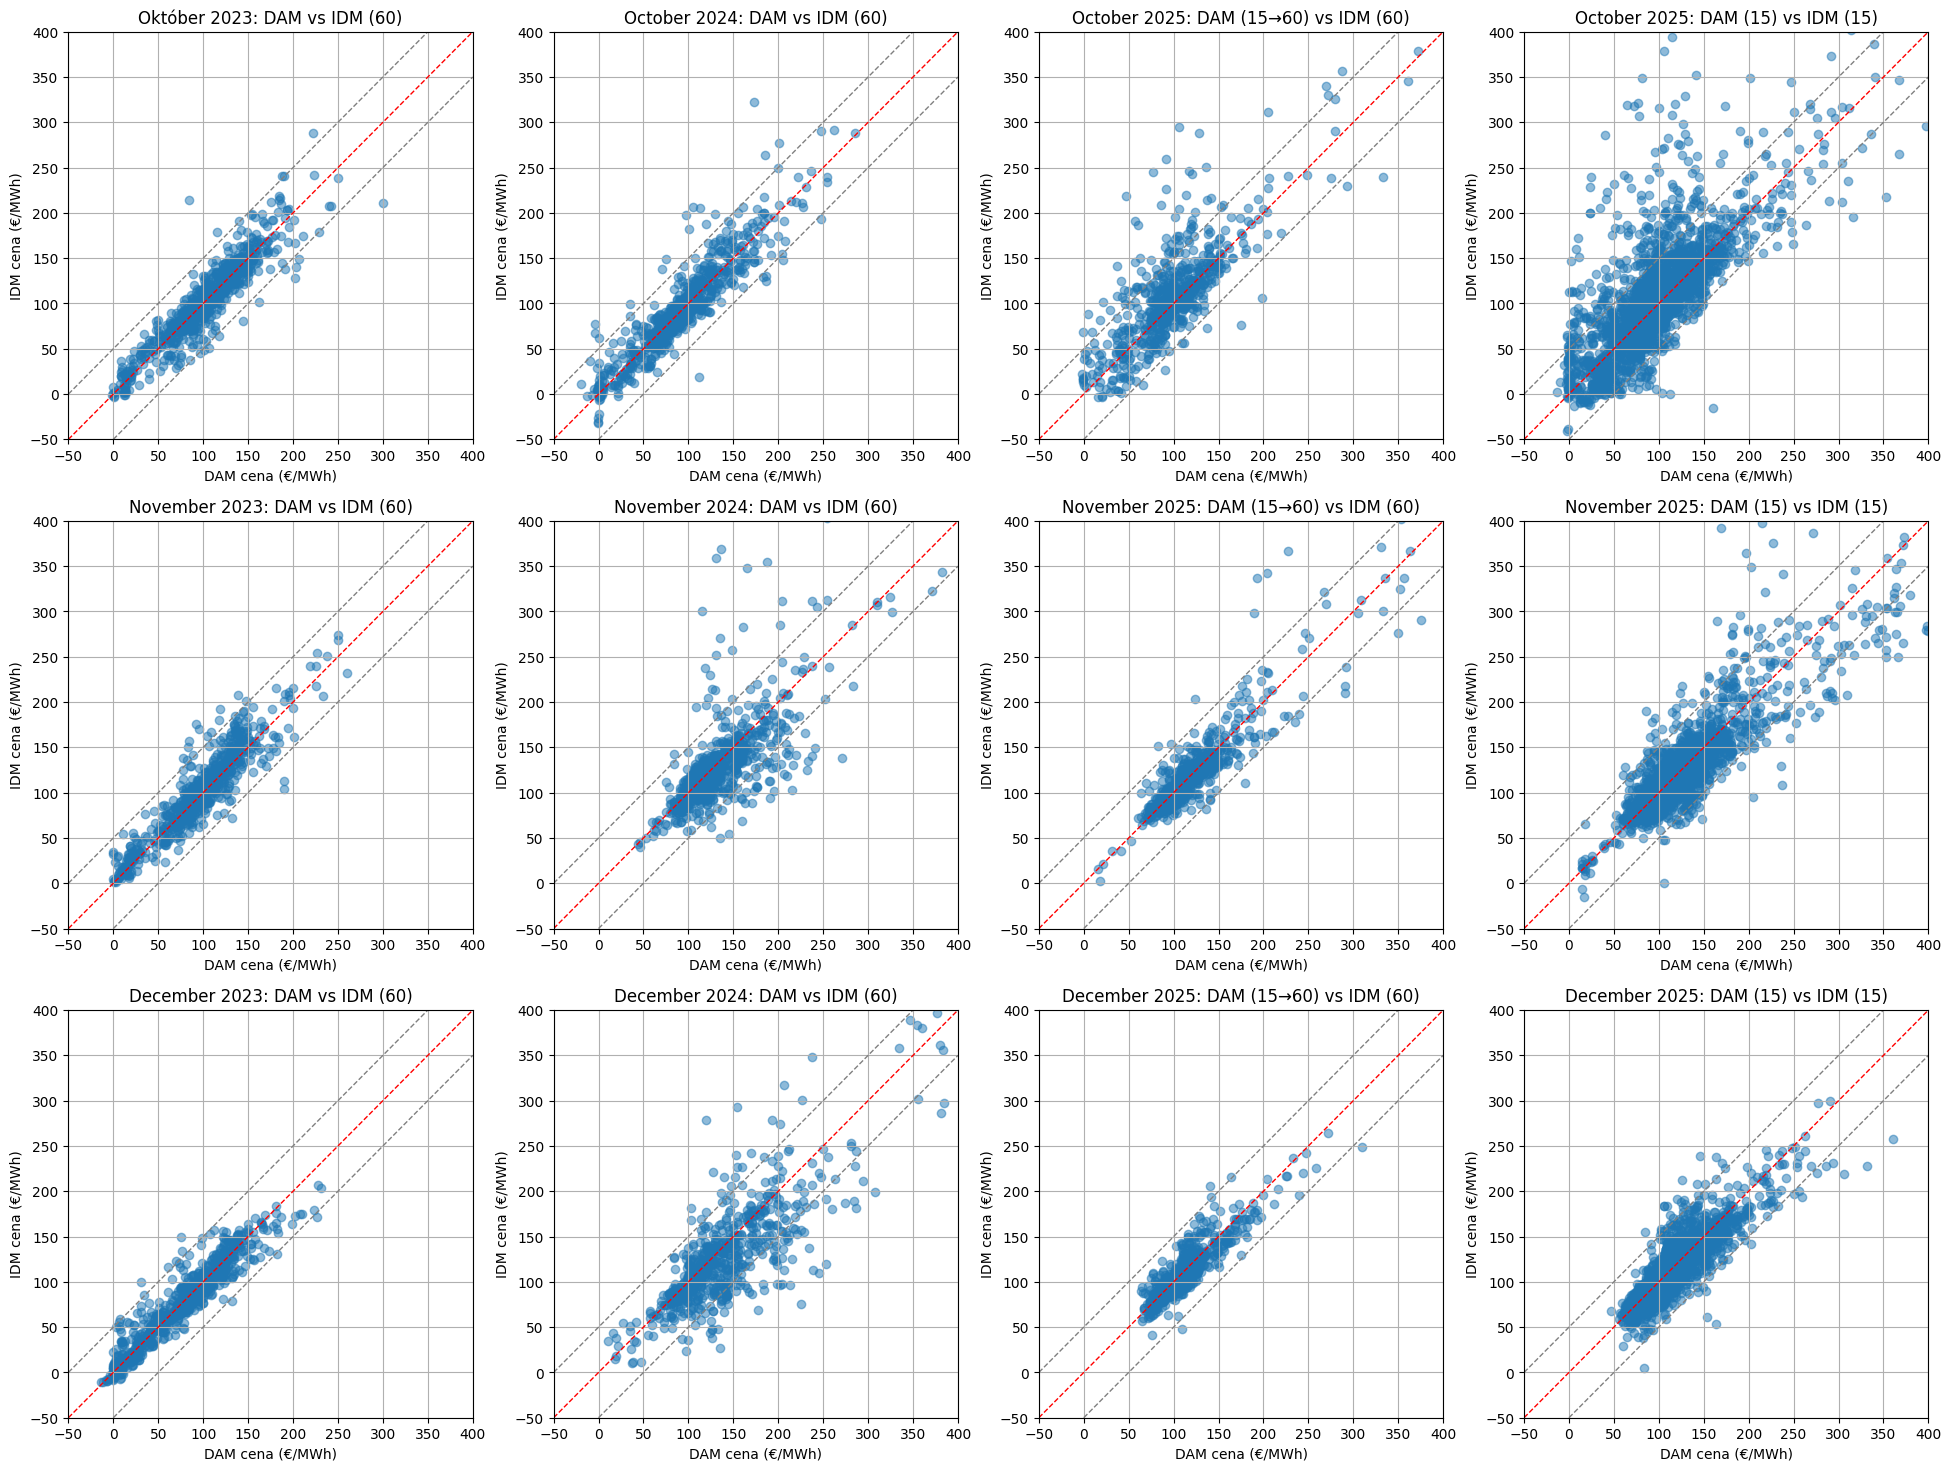

In [18]:
fig, ax = plt.subplots(3, 4, figsize=(24, 18), sharex=False)

def add_dev_scatter(axis, title, hourly):
    axis.plot([-50, 400], [-50, 400], color='red', linestyle='--', linewidth=1, label='x=y')
    axis.plot([-50, 400], [-0, 450], color='gray', linestyle='--', linewidth=1, label='x=y')
    axis.plot([0, 400], [-50, 350], color='gray', linestyle='--', linewidth=1, label='x=y')
    axis.scatter(hourly['DAM_price'], hourly['IDM_price'], alpha=0.5)
    axis.set_title(title)
    axis.set_xlabel("DAM cena (€/MWh)")
    axis.set_ylabel("IDM cena (€/MWh)")
    axis.set_xlim(-50, 400)
    axis.set_ylim(-50, 400)
    axis.grid(True)

add_dev_scatter(ax[0][0], 'Október 2023: DAM vs IDM (60)', mergedO2023)
add_dev_scatter(ax[0][1], 'October 2024: DAM vs IDM (60)', mergedO2024)
add_dev_scatter(ax[0][2], 'October 2025: DAM (15→60) vs IDM (60)', mergedO2025hourlyIDM)
add_dev_scatter(ax[0][3], 'October 2025: DAM (15) vs IDM (15)', mergedO2025quarterlyIDM)

add_dev_scatter(ax[1][0], 'November 2023: DAM vs IDM (60)', mergedN2023)
add_dev_scatter(ax[1][1], 'November 2024: DAM vs IDM (60)', mergedN2024)
add_dev_scatter(ax[1][2], 'November 2025: DAM (15→60) vs IDM (60)', mergedN2025hourlyIDM)
add_dev_scatter(ax[1][3], 'November 2025: DAM (15) vs IDM (15)', mergedN2025quarterlyIDM)

add_dev_scatter(ax[2][0], 'December 2023: DAM vs IDM (60)', mergedD2023)
add_dev_scatter(ax[2][1], 'December 2024: DAM vs IDM (60)', mergedD2024)
add_dev_scatter(ax[2][2], 'December 2025: DAM (15→60) vs IDM (60)', mergedD2025hourlyIDM)
add_dev_scatter(ax[2][3], 'December 2025: DAM (15) vs IDM (15)', mergedD2025quarterlyIDM)
plt.style.use('default')
plt.show()

v roku 2023 IDM silno nasleduje DAM čo je možné vidieť v úzko diagonálnom tvare grafu a taktiež vo výške korelačného koeficientu.

Rok 2024 nadobúda viac extrémov, ktoré je možné vidno cez velký počet osamostatnených bodiek v pravom hornom okraji grafu. Špeciálne v novembri korelačný koeficient padol na 0.656667 čo značí že rozdiel medzi cenou DAM a IDM bol viac nepredvídateľný.

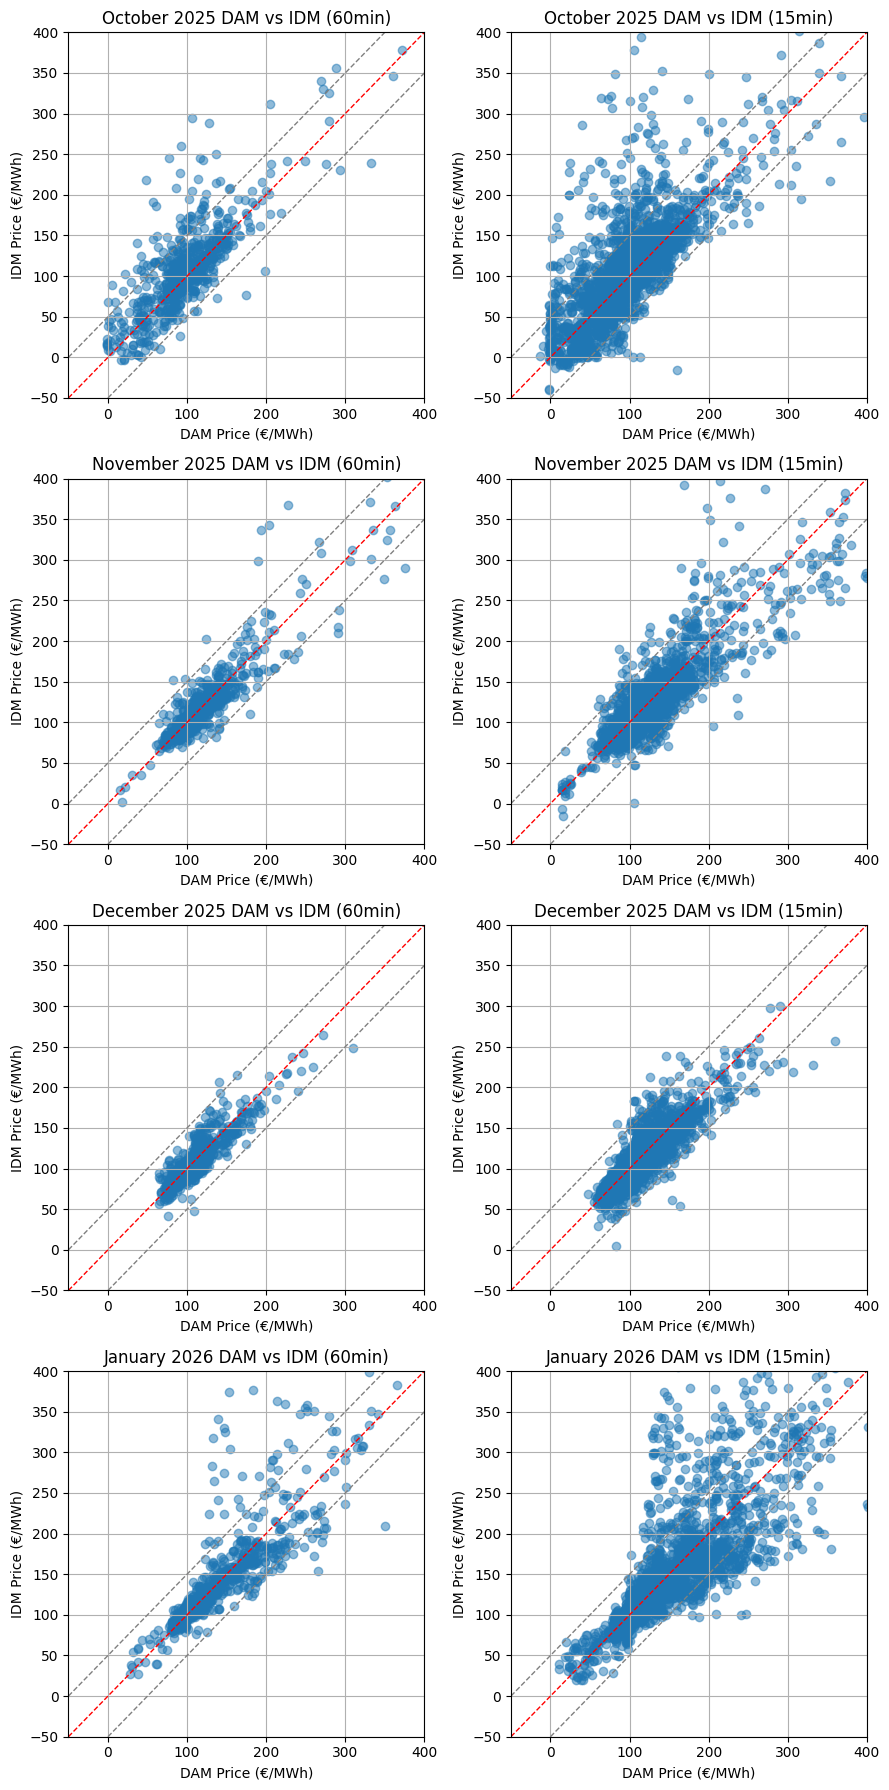

In [11]:
fig, ax = plt.subplots(4, 2, figsize=(9, 18), sharex=False)

add_dev_scatter(ax[0][0], 'October 2025 DAM vs IDM (60min)', mergedO2025hourlyIDM)
add_dev_scatter(ax[0][1], 'October 2025 DAM vs IDM (15min)', mergedO2025quarterlyIDM)
add_dev_scatter(ax[1][0], 'November 2025 DAM vs IDM (60min)', mergedN2025hourlyIDM)
add_dev_scatter(ax[1][1], 'November 2025 DAM vs IDM (15min)', mergedN2025quarterlyIDM)
add_dev_scatter(ax[2][0], 'December 2025 DAM vs IDM (60min)', mergedD2025hourlyIDM)
add_dev_scatter(ax[2][1], 'December 2025 DAM vs IDM (15min)', mergedD2025quarterlyIDM)
add_dev_scatter(ax[3][0], 'January 2026 DAM vs IDM (60min)', mergedJ2026hourlyIDM)
add_dev_scatter(ax[3][1], 'January 2026 DAM vs IDM (15min)', mergedJ2026quarterlyIDM)

plt.tight_layout()
plt.show()



Po prechode denného trhu (DAM) z hodinovej (H) na štvrťhodinovú (15) časovú periódu bolo potrebné upraviť vstupné dáta tak, aby bolo možné porovnanie cien medzi trhmi DAM a IDM. Obchodovanie na vnútrodennom trhu (IDM) je možné v hodinových aj štvrťhodinových periódach, avšak pri 15-minútových periódach je počet realizovaných obchodov výrazne nižší. Tieto obchody sú často uskutočňované z núdzových dôvodov, čo znižuje ich schopnosť spoľahlivo opisovať vývoj cien na trhu.

Z tohto dôvodu sú pre každý analyzovaný mesiac vytvorené tri grafy. Prvý graf znázorňuje ceny DAM agregované zo štvrťhodinových na hodinové periódy, čím je zabezpečená porovnateľnosť s hodinovými IDM cenami. Druhý graf zobrazuje ceny IDM replikované z hodinových na štvrťhodinové periódy, pričom tento postup nepridáva novú informáciu, ale slúži výlučne na umožnenie porovnania s 15 DAM cenami. Tretí graf pracuje s reálnymi štvrťhodinovými IDM cenami, ktoré však trpia nižšou likviditou.

Po prechode z hodinového DAM v septembri je možné pozorovať, že v októbri vykazujú porovnania vyšší rozptyl a menej kompaktný tvar v porovnaní s predchádzajúcimi mesiacmi. V grafoch sa objavuje väčšie množstvo extrémnych hodnôt, čo naznačuje zvýšenú volatilitu po zavedení štvrťhodinových periód. Napriek tomu ceny IDM naďalej sledujú ceny DAM, čo potvrdzuje hodnota korelačného koeficientu 0,785.

V novembri je možné pozorovať čiastočné zúženie bodových rozptylov, čo naznačuje postupnú adaptáciu účastníkov trhu na nový dizajn štvrťhodinovej periódy.

Tieto informácie naznačujú, že zvýšený rozptyl dát bol zväčša zapríčinený zmenou trhu. Obchodujúci nevedeli čo majú od zmeny v trhu čakať čo viedlo k dočasnej neistote a volatilite cien. Trh sa postupne stabilizoval a korelácia medzi DAM a IDM opäť stúpla naspäť v novembri. November avšak naďalej zaznamenáva zvýšený počet extrémov, tento jav môže byť zapríčinený kratším časovým intervalom.

Porovnanie medzi agregáciou a replikáciou:
Pri agregácií spájame 4 štvrťhodinové body do jedného hodinového, čo vyhladzuje výkyvy a extrémy z trhu. Následne teda ukazuje stabilnejší a kompaktnejší trend. Zapríčinuje to, že graf vyzerá menej volatilne.

Pri replikácií replikované ceny nezobrazujú skutočné pohyby, všetky body nadobúdajúm rovnaku hodnotu. Extrémy, ktoré by sa v 15 IDM objavili, sa v replikovanom grafe neprejavia, čo môže spôsobiť dojem, že DAM ceny majú vyššiu volatilitu než IDM.



Deviation calculation

In [12]:
def calc_dev_print(data, text):
    data['dev'] = (data['DAM_price'] - data['IDM_price'])
    print(text)
    print("mean: " + str(data['dev'].mean()))
    print("median: " + str(data['dev'].median()))
    print("std: " + str(data['dev'].std()))
    print("")

calc_dev_print(mergedO2023, "October 2024")
calc_dev_print(mergedN2023, "November 2024")

calc_dev_print(mergedO2024, "October 2024")
calc_dev_print(mergedN2024, "November 2024")

calc_dev_print(mergedO2025hourlyIDM, "October dam15 to 60")
calc_dev_print(mergedO2025quarterlyIDM, "October idm15")

calc_dev_print(mergedN2025hourlyIDM, "November dam15 to 60")
calc_dev_print(mergedN2025quarterlyIDM, "November idm15")

calc_dev_print(mergedD2025hourlyIDM, "December dam15 to 60")
calc_dev_print(mergedD2025quarterlyIDM, "December idm15")

calc_dev_print(mergedJ2026hourlyIDM, "January dam15 to 60")
calc_dev_print(mergedJ2026quarterlyIDM, "January idm15")


October 2024
mean: -0.35527516778523527
median: -1.1199999999999903
std: 17.604420951981275

November 2024
mean: -4.502263888888889
median: -3.5749999999999886
std: 17.991056525270974

October 2024
mean: -2.0017583892617448
median: -0.789999999999992
std: 20.21851451090231

November 2024
mean: -10.55138888888889
median: 3.144999999999996
std: 91.92412990152127

October dam15 to 60
mean: -9.44785666218035
median: -3.2549999999999955
std: 32.1285864437046

October idm15
mean: -8.556212751212753
median: -2.604999999999997
std: 37.191574872440256

November dam15 to 60
mean: -0.09397222222222194
median: 0.6287499999999966
std: 21.392846200372077

November idm15
mean: 1.696974555594284
median: 1.7099999999999795
std: 22.872901246132326

December dam15 to 60
mean: 0.5728293010752696
median: 1.1437499999999972
std: 13.137933349948925

December idm15
mean: 1.4347998654557679
median: 1.0200000000000102
std: 15.91361070451175

January dam15 to 60
mean: -1.2623084677419345
median: 0.91249999999999

Priemer aj medián sa zvýšili v októbri čo znamená že rozlišnosť medzi DAM a IDM sa zväčšila.

Štandardná odchylka sa taktiež zväčšila čo naznačuje že trh sa stal viac volatilný a nepredvídateľný.

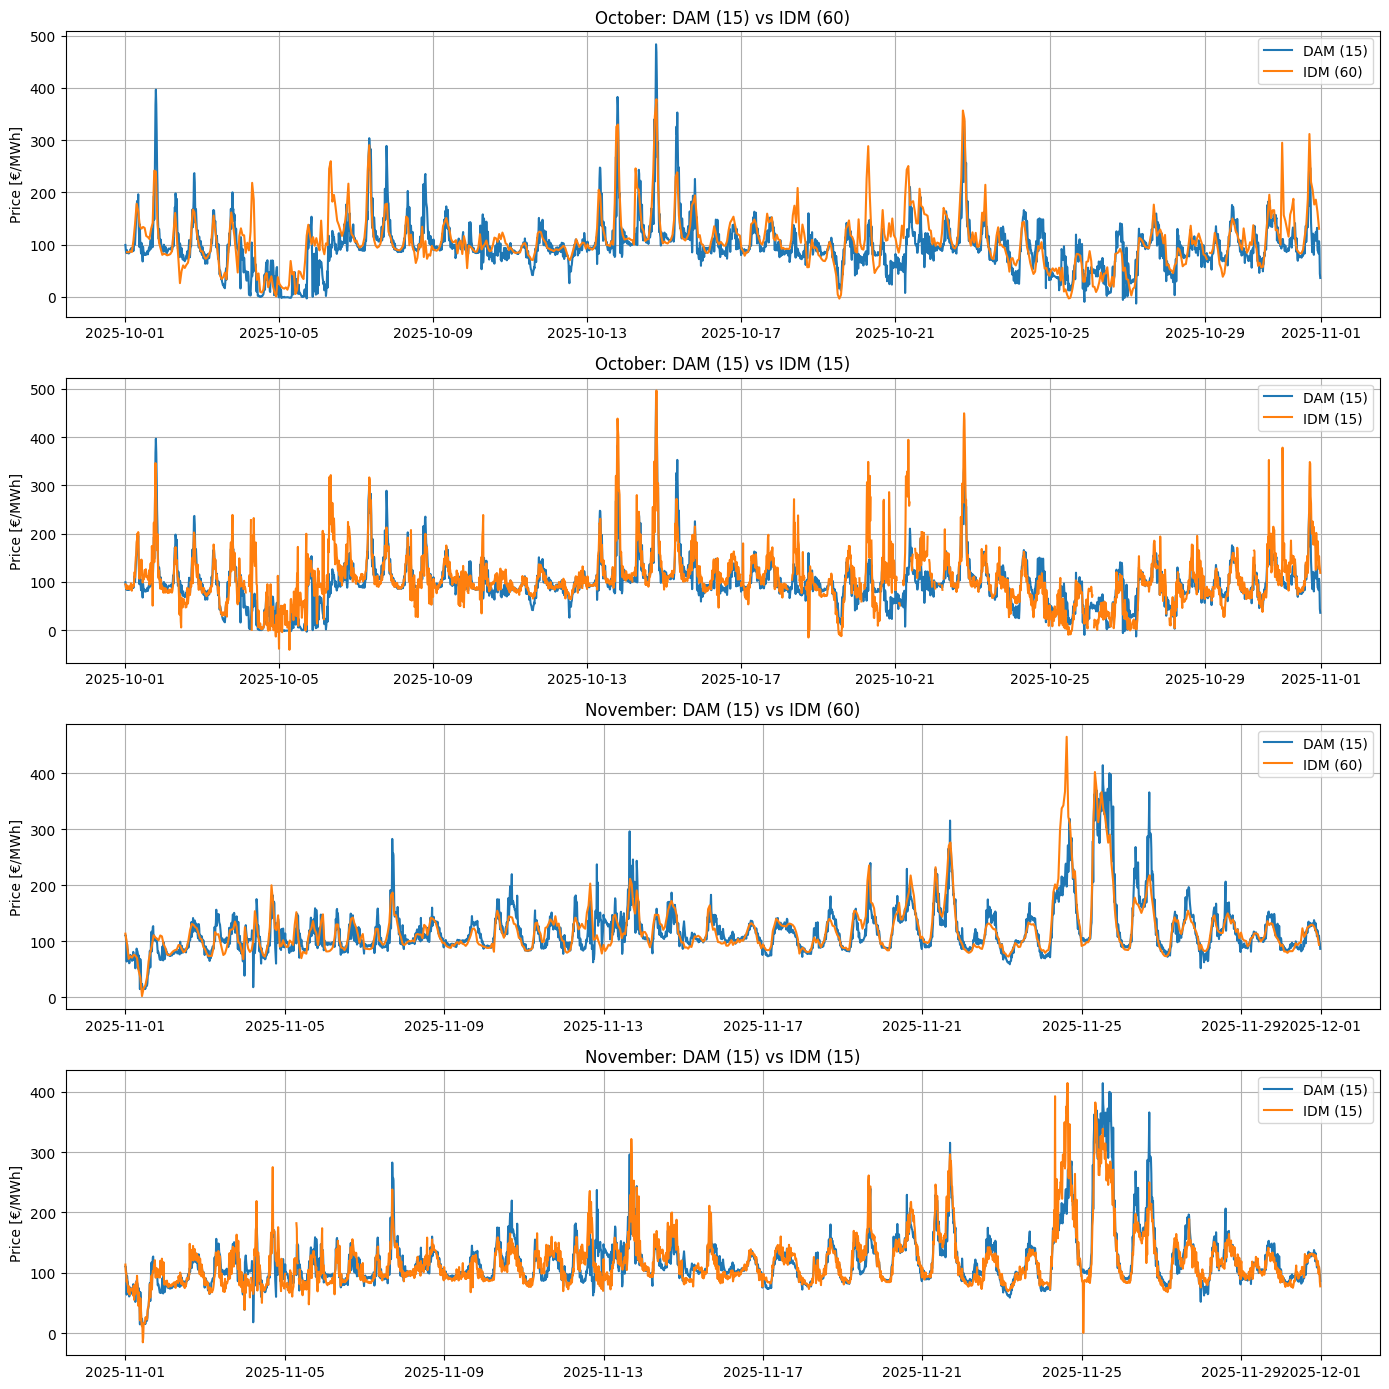

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(4, 1, figsize=(14, 14), sharex=False)

def plotprice_dam_idm(axis,title,dam,dam_gran,idm,idm_gran):
    axis.plot(dam['deliveryStartBA'], dam['price'], label=f'DAM ({dam_gran})')
    axis.plot(idm['deliveryStartBA'], idm['priceWeightedAverage'], label=f'IDM ({idm_gran})')
    axis.set_title(title)
    axis.set_ylabel("Price [€/MWh]")
    axis.legend()
    axis.grid(True)

plotprice_dam_idm(ax[0],"October: DAM (15) vs IDM (60)",october2025DAM,"15", october2025IDM60,"60")
plotprice_dam_idm(ax[1],"October: DAM (15) vs IDM (15)",october2025DAM,"15", october2025IDM15,"15")
plotprice_dam_idm(ax[2],"November: DAM (15) vs IDM (60)",november2025DAM,"15", november2025IDM60,"60")
plotprice_dam_idm(ax[3],"November: DAM (15) vs IDM (15)",november2025DAM,"15", november2025IDM15,"15")

plt.tight_layout()
plt.show()


V septembri IDM náusleduje DAM o dosť presnejšie pričom v októbri až tak moc nie. Je možné že časť tejto odchylky je z dôvodu že IDM má iba average hourly price.

deviation

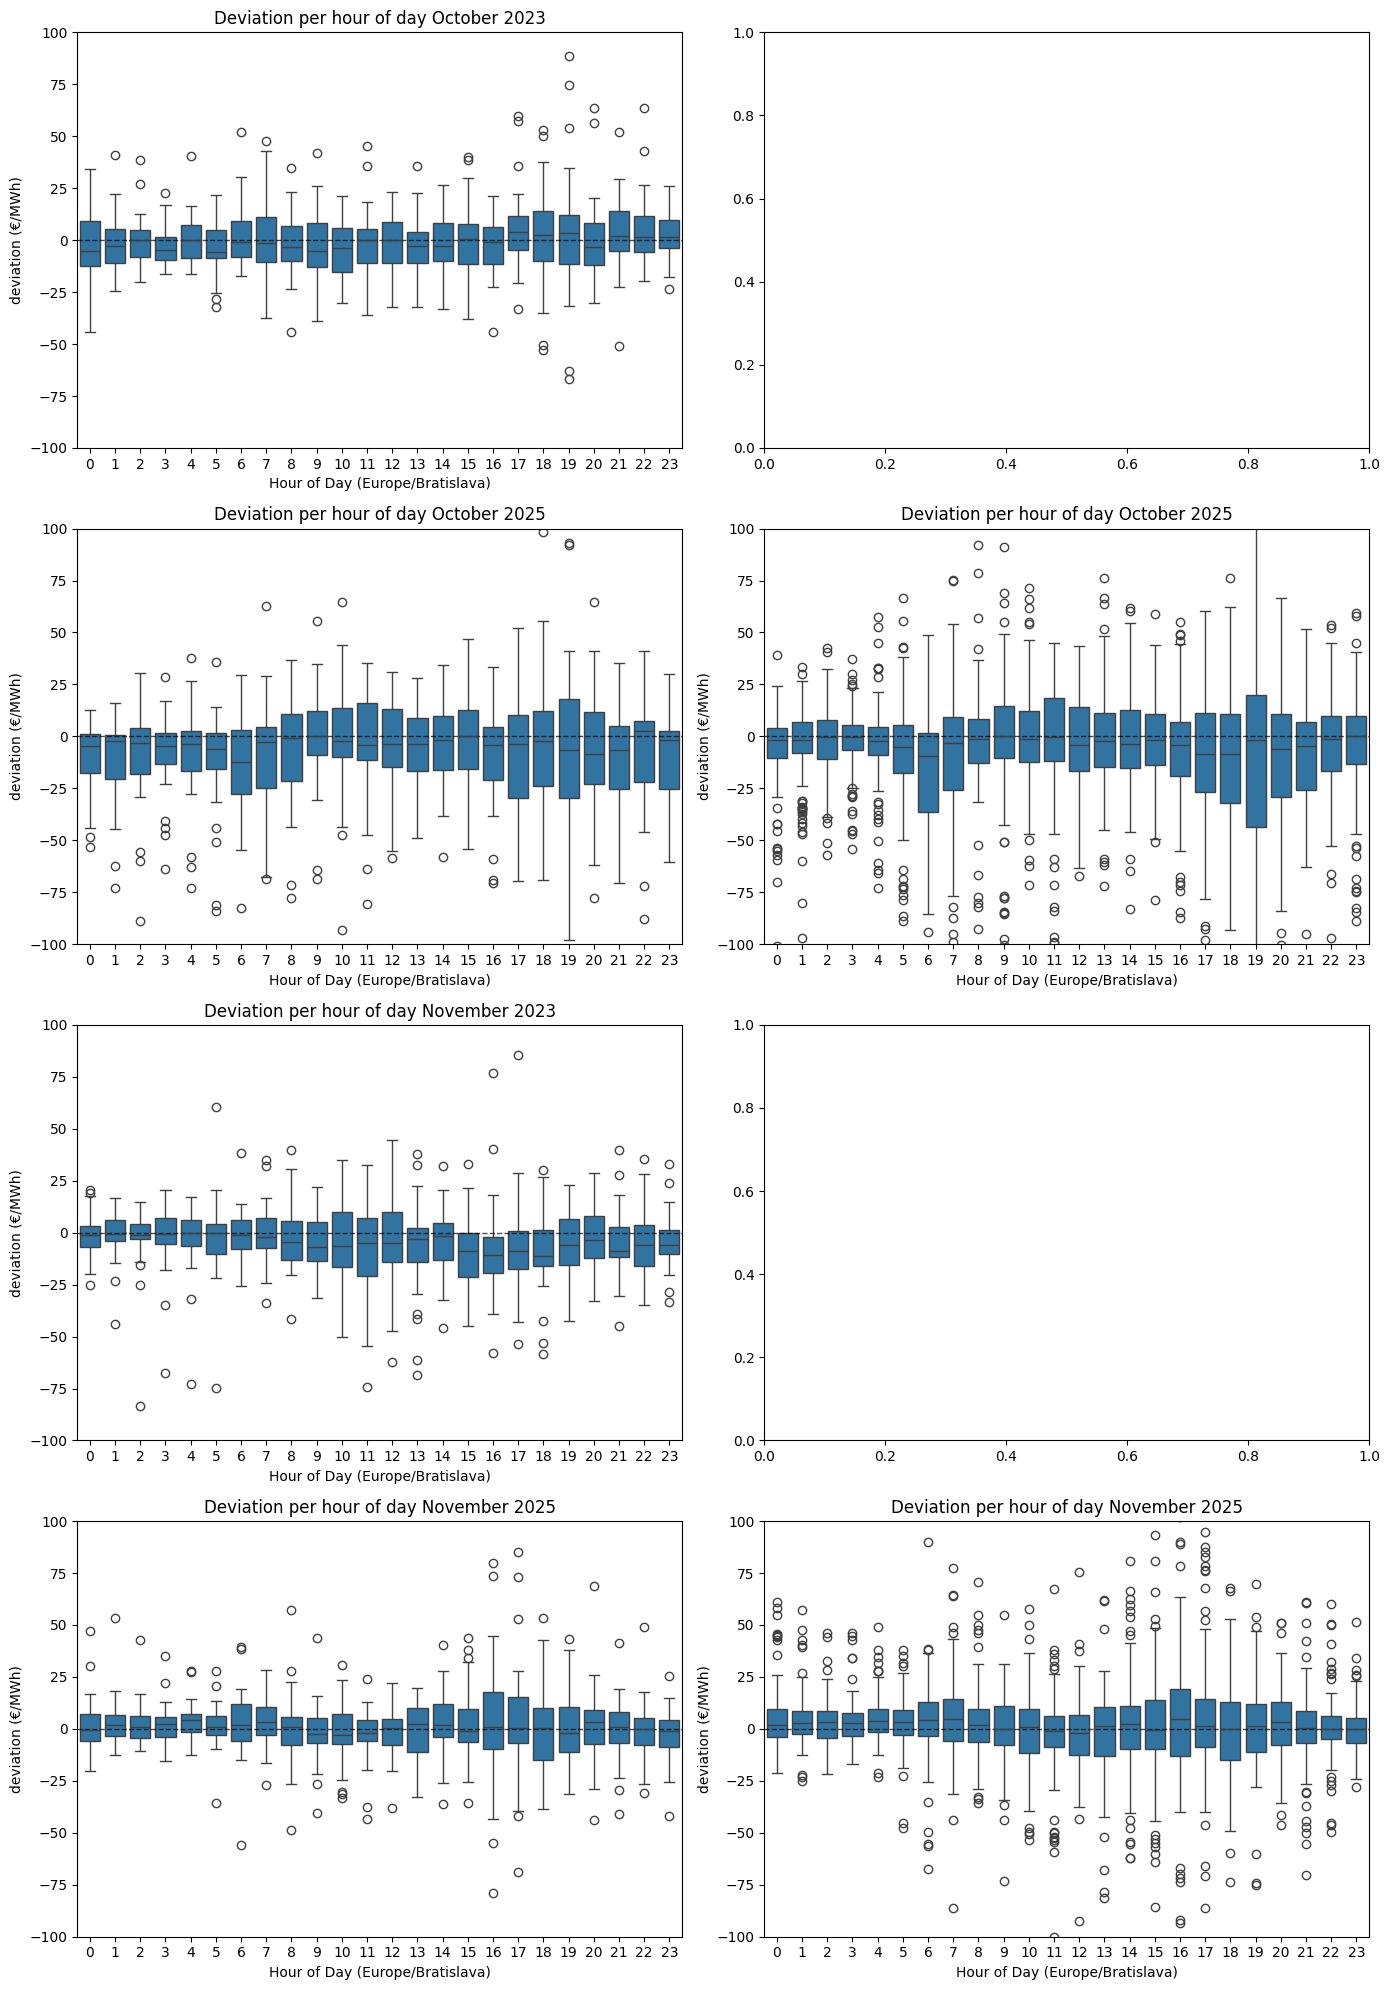

In [14]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)


fig, ax = plt.subplots(4,2, figsize=(14,20))

def add_dev_boxplot(axis, title, data):
    data['hour'] = data['deliveryStartBA'].dt.hour

    sns.boxplot(data=data, x='hour', y='dev', ax=axis)
    axis.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    axis.set_title(title)
    axis.set_xlabel('Hour of Day (Europe/Bratislava)')
    axis.set_ylabel('deviation (€/MWh)')
    axis.set_ylim(-100, 100)


add_dev_boxplot(ax[0][0], "Deviation per hour of day October 2023", mergedO2023)
add_dev_boxplot(ax[1][0], "Deviation per hour of day October 2025", mergedO2025hourlyIDM)
add_dev_boxplot(ax[1][1], "Deviation per hour of day October 2025", mergedO2025quarterlyIDM)
add_dev_boxplot(ax[2][0], "Deviation per hour of day November 2023", mergedN2023)
add_dev_boxplot(ax[3][0], "Deviation per hour of day November 2025", mergedN2025hourlyIDM)
add_dev_boxplot(ax[3][1], "Deviation per hour of day November 2025", mergedN2025quarterlyIDM)

plt.tight_layout()
plt.show()


In [15]:

import data_processor as dm

october2025IDM60clean = october2025IDM60[['priceWeightedAverage','deliveryStart']].set_index('deliveryStart')
october2025IDM60replic = october2025IDM60clean.resample('15min').ffill()
october2025IDM60replic = october2025IDM60replic.reset_index()

mergedO2025replicIDM = merge_onDeliveryStart(october2025DAM,october2025IDM60replic)

dm.add_time_features(mergedO2025replicIDM)

november2025IDM60clean = november2025IDM60[['priceWeightedAverage','deliveryStart']].set_index('deliveryStart')
november2025IDM60replic = november2025IDM60clean.resample('15min').ffill()
november2025IDM60replic = november2025IDM60replic.reset_index()

mergedN2025replicIDM = merge_onDeliveryStart(november2025DAM,november2025IDM60replic)

dm.add_time_features(mergedN2025replicIDM)

,deliveryStart,DAM_price,IDM_price,weekday,quarterHour,hour
0,2025-10-31 23:00:00+00:00,110.43,113.44,4,0,23
1,2025-10-31 23:15:00+00:00,110.00,113.44,4,1,23
2,2025-10-31 23:30:00+00:00,96.95,113.44,4,2,23
3,2025-10-31 23:45:00+00:00,63.66,113.44,4,3,23
4,2025-11-01 00:00:00+00:00,94.75,94.33,5,0,0
...,...,...,...,...,...,...
2872,2025-11-30 21:00:00+00:00,119.46,111.06,6,0,21
2873,2025-11-30 21:15:00+00:00,115.84,111.06,6,1,21
2874,2025-11-30 21:30:00+00:00,112.01,111.06,6,2,21
2875,2025-11-30 21:45:00+00:00,105.21,111.06,6,3,21


In [16]:
def plot_dev_boxplots(df, title_prefix=""):
    warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

    df = df.copy()

    df['dev'] = df['DAM_price'] - df['IDM_price']

    quarter_order = [0, 1, 2, 3]

    fig, axes = plt.subplots(6, 4, figsize=(16, 24), sharey=True)
    axes = axes.flatten()

    for h in range(24):
        ax = axes[h]

        df_h = df[df['hour'] == h]

        sns.boxplot(
            data=df_h,
            x='quarterHour',
            y='dev',
            order=quarter_order,
            ax=ax
        )

        ax.axhline(0, color='black', linestyle='--', linewidth=1)

        ax.set_ylim(-150, 150)

        ax.set_title(f'{title_prefix}Hour {h:02d}')
        ax.set_xlabel('')
        ax.set_ylabel('DAM - IDM (€/MWh)' if h % 4 == 0 else '')

    for i in range(24, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

KeyError: 'hour'

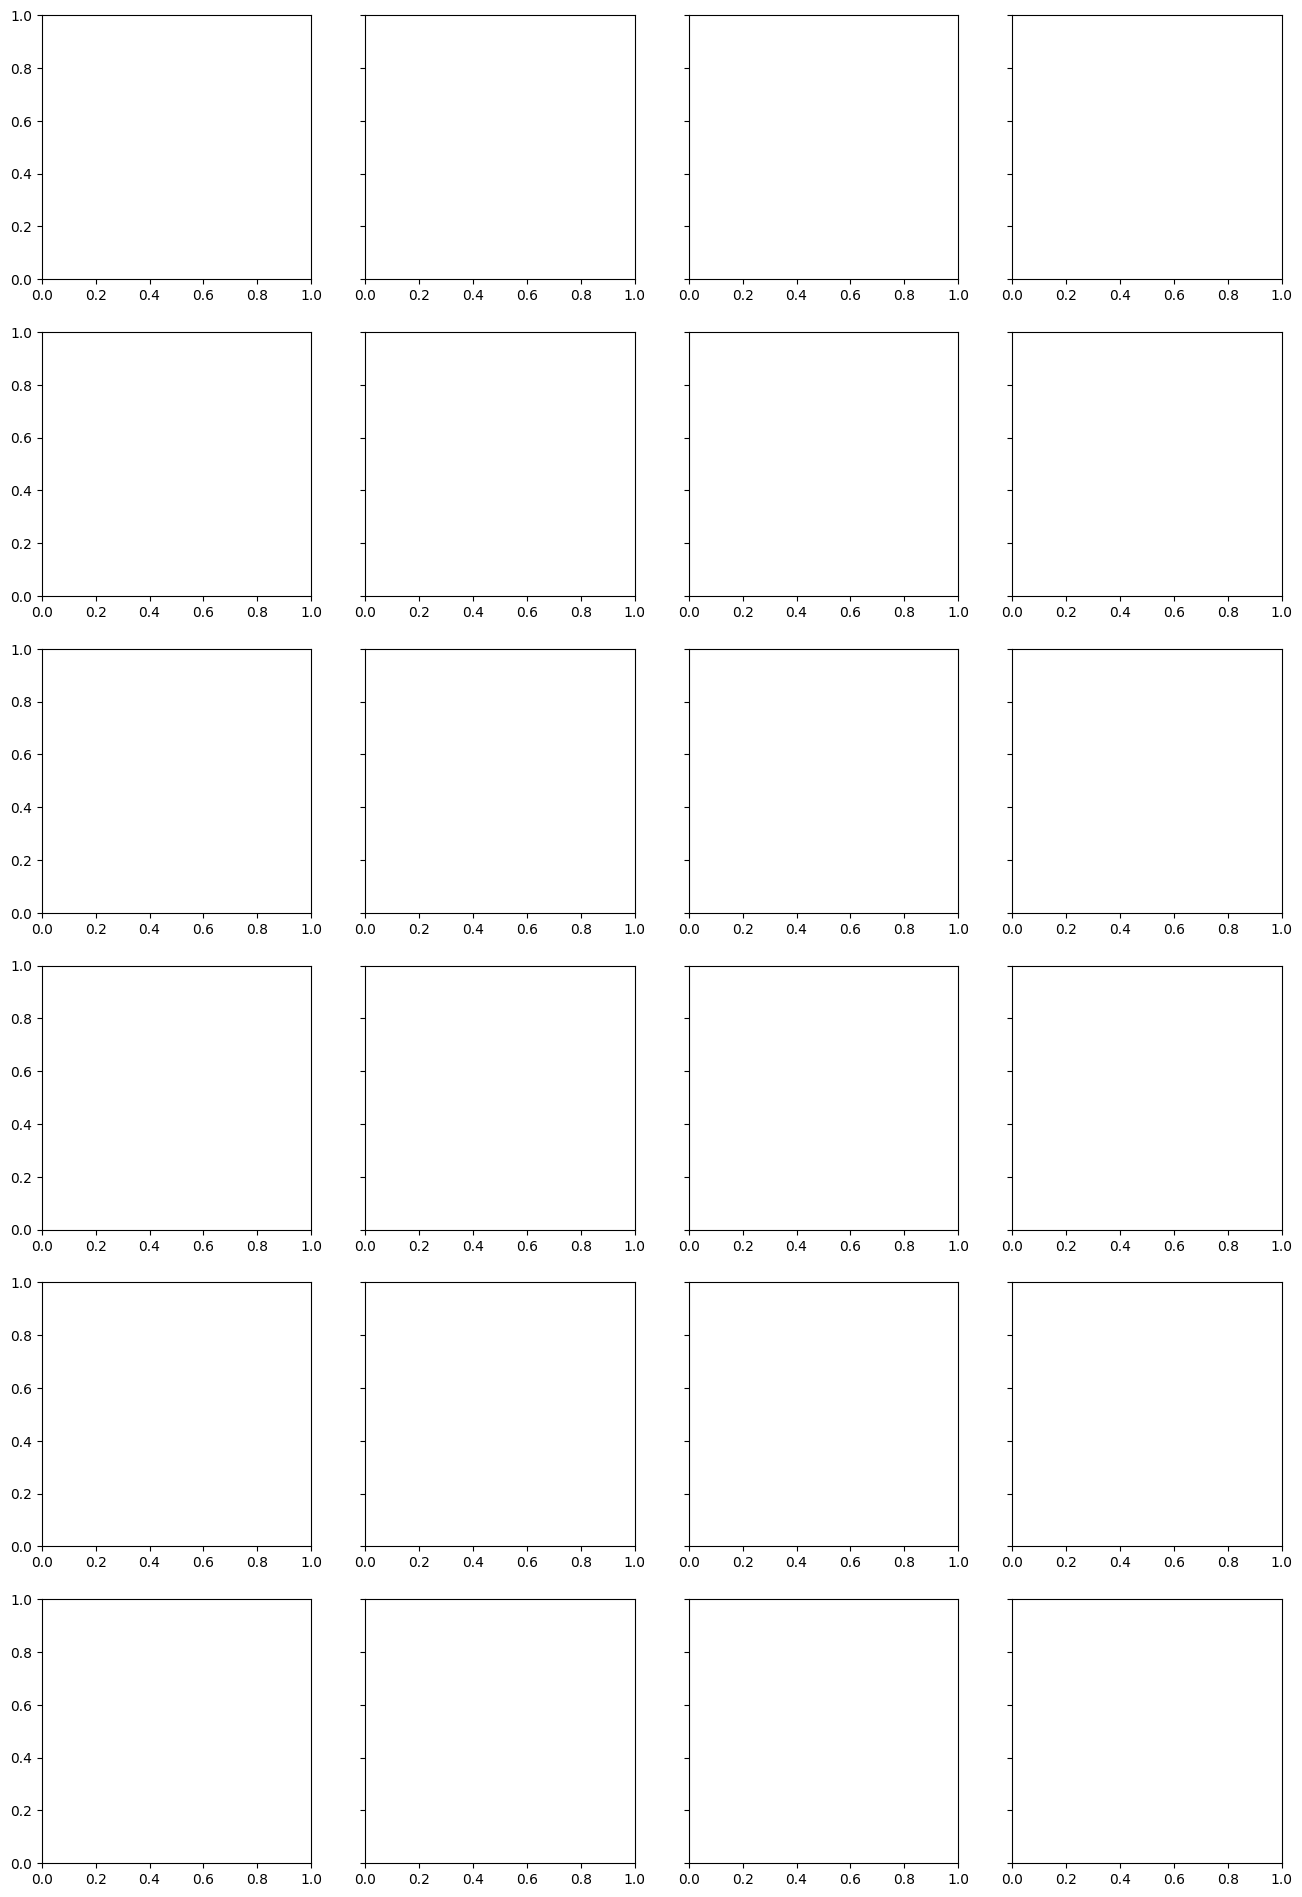

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
mergedO2025replicIDM['dev'] = mergedO2025replicIDM['DAM_price'] - mergedO2025replicIDM['IDM_price']

plot_dev_boxplots(mergedO2025replicIDM)

In [ ]:
summary = (
    mergedO2025replicIDM
    .groupby(['hour', 'quarterHour'])['dev']
    .agg(
        mean='mean',
        median='median',
        std='std',
        min='min',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        max='max'
    )
    .reset_index()
)
print(summary['mean'].abs().mean())
summary

In [ ]:
plot_dev_boxplots(mergedN2025replicIDM)

In [ ]:
mergedN2025replicIDM['dev'] = mergedN2025replicIDM['DAM_price'] - mergedN2025replicIDM['IDM_price']
summary = (
    mergedN2025replicIDM
    .groupby(['hour', 'quarterHour'])['dev']
    .agg(
        mean='mean',
        median='median',
        std='std',
        min='min',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        max='max'
    )
    .reset_index()
)
print(summary['mean'].abs().mean())
summary

In [ ]:
# dm.add_time_features(mergedN2025quarterlyIDM)
# plot_dev_boxplots(mergedN2025quarterlyIDM)

In [ ]:
# summary = (
#     mergedN2025quarterlyIDM
#     .groupby(['hour', 'quarterHour'])['dev']
#     .agg(
#         mean='mean',
#         median='median',
#         std='std',
#         min='min',
#         q25=lambda x: x.quantile(0.25),
#         q75=lambda x: x.quantile(0.75),
#         max='max'
#     )
#     .reset_index()
# )
# print(summary['mean'].abs().mean())
# summary

rozdiely medzi IDM a DAM sú najväčšie 19teho v danom mesiaci a potom zaujímavý menší skok okolo 7meho dňa. Celkovo ako sme už predtým zistili sa odchylka z mesiaca zvýšila kvôl

In [ ]:
hours = range(24)
october2025DAM['minute'] = october2025DAM['deliveryStartBA'].dt.minute
october2025DAM['quarter'] = october2025DAM['minute'] // 15
october2025DAM['hour'] = october2025DAM['deliveryStartBA'].dt.hour
october2025IDM15['minute'] = october2025IDM15['deliveryStartBA'].dt.minute
october2025IDM15['quarter'] = october2025IDM15['minute'] // 15
october2025IDM15['hour'] = october2025IDM15['deliveryStartBA'].dt.hour
october2025DAM['market'] = 'DAM'
october2025IDM15['market'] = 'IDM15'

october2025DAM['priceV'] = october2025DAM['price']
october2025IDM15['priceV'] = october2025IDM15['priceWeightedAverage']
fig, axes = plt.subplots(6, 4, figsize=(18, 20))
axes = axes.flatten()
df_long = pd.concat([
    october2025DAM[['hour', 'quarter', 'market', 'priceV']].reset_index(drop=True),
    october2025IDM15[['hour', 'quarter', 'market', 'priceV']].reset_index(drop=True)
], ignore_index=True)



for i, hour in enumerate(hours):
    ax = axes[i]

    subset = df_long[df_long['hour'] == hour]
    sns.violinplot(
        data=subset,
        x='quarter',
        y='priceV',
        hue='market',
        split=True,
        inner='quartile',
        cut=1,
        density_norm='width',
        ax=ax
    )
    ax.set_title(f'Hour {hour:02d}')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['00–15', '15–30', '30–45', '45–60'])
    ax.set_ylim(-50, 400)


    if i % 4 == 0:
        ax.set_ylabel('Price (€/MWh)')
    ax.grid(True)

plt.tight_layout()
plt.show()

Ceny v hodinách 0 až 4 sú celkom ustálené pričom prvý väčší nárast nastáva v tretiom kvartáli piatej hodiny. Od tohto bodu si taktiež môžeme všimnúť že IDM začína nadobúdať podstatne väčšie hodnoty ako DAM. Trh nadobúda lokálne špičky v 7 a 8 hodine a potom následne klesá v 9tej pričom sa okolo 12tej hodiny ustáli a a okolo 14tej hodiny začína znova rásť a koncom 18tej hodiny nadobúda lokálne aj globálne maximum. Zbytok dňa následne ceny padajú až sa znova cez noc ustália.

Je možné si povšimnúť že teda IDM systematicky nadobúda trošku vyššie hodnoty  ako DAM.

0-4 hodina: nízke ceny cez noc až tak moc sa neobchoduje

5-6 hodina: rast cien

7-8 hodina: lokálna špička cien, najviac zobchodované množstvo

9-13 hodina: pokles a ustálenie cien, v porovnaní s nocou však väčší počet predaja

14-17 hodina: nárast cien

18-19 hodina: globálna špička cien

20-23 hodina: pokles cien a následné ustálenie

V hodinách kde ceny rastú je možné si povšimnúť že prvá 15 minutová perióda nadobúda nižšie hodnoty ako tie následujúce. Naopak pri klesajúcich hodinách cena začiatkom hodiny vždy "povyskočí" a pokračuje v klesaní.
Nočné hodiny sú kludné a taktiež aj obedné hodiny. Vrchol obchodovania teda nastáva ranných a večerných hodinách okolo 7 a 19 tej hodiny.

November

In [ ]:
hours = range(24)
november2025DAM['minute'] = november2025DAM['deliveryStartBA'].dt.minute
november2025DAM['quarter'] = november2025DAM['minute'] // 15
november2025DAM['hour'] = november2025DAM['deliveryStartBA'].dt.hour
november2025IDM15['minute'] = november2025IDM15['deliveryStartBA'].dt.minute
november2025IDM15['quarter'] = november2025IDM15['minute'] // 15
november2025IDM15['hour'] = november2025IDM15['deliveryStartBA'].dt.hour
november2025DAM['market'] = 'DAM'
november2025IDM15['market'] = 'IDM15'

november2025DAM['priceV'] = november2025DAM['price']
november2025IDM15['priceV'] = november2025IDM15['priceWeightedAverage']
fig, axes = plt.subplots(6, 4, figsize=(18, 20))
axes = axes.flatten()
df_long = pd.concat([
    november2025DAM[['hour', 'quarter', 'market', 'priceV']].reset_index(drop=True),
    november2025IDM15[['hour', 'quarter', 'market', 'priceV']].reset_index(drop=True)
], ignore_index=True)



for i, hour in enumerate(hours):
    ax = axes[i]

    subset = df_long[df_long['hour'] == hour]
    sns.violinplot(
        data=subset,
        x='quarter',
        y='priceV',
        hue='market',
        split=True,
        inner='quartile',
        cut=0.2,
        density_norm='width',
        ax=ax
    )
    ax.set_title(f'Hour {hour:02d}')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['00–15', '15–30', '30–45', '45–60'])
    ax.set_ylim(-50, 400)

    if i % 4 == 0:
        ax.set_ylabel('Price (€/MWh)')
    ax.grid(True)

plt.tight_layout()
plt.show()

November následuje podobný trend ako október.Noci bývajú kludné a ceny začínajú rásť okolo 4-5 hodiny, v 7-8 nadobúdajú lokálne maximum a následne klesajú kde sa okolo 11 hodiny ustália.
Narozdiel od októbra však večeré špičky sa presunuli o pár hodín dopredu kde ceny sú pri špičke už v 15tej hodine a ťahajú sa až do 17tej hodiny. Od 18te hodiny ceny začínajú pomaly klesať kde zase naberajú lokálne minimum v nočných hodinách.

DAM taktiež vyzerá byť konzistentne vyššie ako IDM.

V porovnaní s ním je však možné si pozorovať placatejší tvar plotov a teda o dosť menší rozptyl cien.

In [ ]:
hours = range(24)
december2025DAM['minute'] = december2025DAM['deliveryStartBA'].dt.minute
december2025DAM['quarter'] = december2025DAM['minute'] // 15
december2025DAM['hour'] = december2025DAM['deliveryStartBA'].dt.hour
december2025IDM15['minute'] = december2025IDM15['deliveryStartBA'].dt.minute
december2025IDM15['quarter'] = december2025IDM15['minute'] // 15
december2025IDM15['hour'] = december2025IDM15['deliveryStartBA'].dt.hour
december2025DAM['market'] = 'DAM'
december2025IDM15['market'] = 'IDM15'

december2025DAM['priceV'] = december2025DAM['price']
december2025IDM15['priceV'] = december2025IDM15['priceWeightedAverage']
fig, axes = plt.subplots(6, 4, figsize=(18, 20))
axes = axes.flatten()
df_long = pd.concat([
    december2025DAM[['hour', 'quarter', 'market', 'priceV']].reset_index(drop=True),
    december2025IDM15[['hour', 'quarter', 'market', 'priceV']].reset_index(drop=True)
], ignore_index=True)



for i, hour in enumerate(hours):
    ax = axes[i]

    subset = df_long[df_long['hour'] == hour]
    sns.violinplot(
        data=subset,
        x='quarter',
        y='priceV',
        hue='market',
        split=True,
        inner='quartile',
        cut=30,
        density_norm='width',
        ax=ax
    )
    ax.set_title(f'Hour {hour:02d}')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['00–15', '15–30', '30–45', '45–60'])
    ax.set_ylim(-50, 250)

    if i % 4 == 0:
        ax.set_ylabel('Price (€/MWh)')
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(6, 4, figsize=(18, 20))
january2026DAM['minute'] = january2026DAM['deliveryStartBA'].dt.minute
january2026DAM['quarter'] = january2026DAM['minute'] // 15
january2026DAM['hour'] = january2026DAM['deliveryStartBA'].dt.hour
january2026IDM15['minute'] = january2026IDM15['deliveryStartBA'].dt.minute
january2026IDM15['quarter'] = january2026IDM15['minute'] // 15
january2026IDM15['hour'] = january2026IDM15['deliveryStartBA'].dt.hour
january2026DAM['market'] = 'DAM'
january2026IDM15['market'] = 'IDM15'

january2026DAM['priceV'] = january2026DAM['price']
january2026IDM15['priceV'] = january2026IDM15['priceWeightedAverage']
axes = axes.flatten()
df_long = pd.concat([
    january2026DAM[['hour', 'quarter', 'market', 'priceV']].reset_index(drop=True),
    january2026IDM15[['hour', 'quarter', 'market', 'priceV']].reset_index(drop=True),
    january2026DAM[['hour', 'quarter', 'market', 'priceV']].reset_index(drop=True),
    january2026IDM15[['hour', 'quarter', 'market', 'priceV']].reset_index(drop=True)
], ignore_index=True)



for i, hour in enumerate(hours):
    ax = axes[i]

    subset = df_long[df_long['hour'] == hour]
    sns.violinplot(
        data=subset,
        x='quarter',
        y='priceV',
        hue='market',
        split=True,
        inner='quartile',
        cut=1,
        density_norm='width',
        ax=ax
    )
    ax.set_title(f'Hour {hour:02d}')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['00–15', '15–30', '30–45', '45–60'])
    ax.set_ylim(-100, 400)


    if i % 4 == 0:
        ax.set_ylabel('Price (€/MWh)')
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from ridgeplot import ridgeplot

mergedO2025quarterlyIDM['hour'] = mergedO2025quarterlyIDM['deliveryStartBA'].dt.hour

hours = sorted(mergedO2025quarterlyIDM['hour'].unique())

samples = [
    mergedO2025quarterlyIDM.loc[mergedO2025quarterlyIDM['hour'] == h, 'dev'].dropna().values
    for h in hours
]

labels = [f"{h:02d}:00" for h in hours]

fig = ridgeplot(
    samples=samples,
    labels=labels,
    bandwidth=3,
    colorscale="viridis",
    colormode="row-index",
    opacity=0.6,
)

fig.update_layout(
    title="October: DAM - IDM (€/MWh)",
    height=1000,
    width=1200,
    font_size=14,
    yaxis_title="Hour",
    xaxis_title="Price difference (€/MWh)",
    showlegend=False,)

fig.show()




In [ ]:
mergedO2025hourlyIDM['hour'] = mergedO2025hourlyIDM['deliveryStartBA'].dt.hour

hours = sorted(mergedO2025hourlyIDM['hour'].unique())

samples = [
    mergedO2025hourlyIDM.loc[mergedO2025hourlyIDM['hour'] == h, 'dev'].dropna().values
    for h in hours
]

labels = [f"{h:02d}:00" for h in hours]

fig = ridgeplot(
    samples=samples,
    labels=labels,
    bandwidth=3,
    colorscale="viridis",
    colormode="row-index",
    opacity=0.6,
)

fig.update_layout(
    title="DAM - IDM (€/MWh)",
    height=1000,
    width=1200,
    font_size=14,
    yaxis_title="Hour",
    xaxis_title="Price difference (€/MWh)",
    showlegend=False,)

fig.show()


Prvý set grafov August:

Odchylka si drží špicatý tvar do približne 7 hodiny kde následne začne trochu placatieť avšak rozdiel sa stále točí v blízkosti nuly. Najväčšie rozdiely nastávajú v 20tej hodine a v nočných hodinách 23-5 sa IDM najmenej líši od DAM

0-5 hodina: špicatý tvar nie veľký roztpyl

6-8 hodina: pomalé klesanie špičky

9-18 hodina: placatejší tvar

19-20 hodina: najväčší rozptyl čo sa týka odchylky

21-23 hodina: stabilizácia a nárast špičky

Druhý set grafov október:
Je rozdelený na dve, v jednom je vykonaná agregácia DAM na 60 minutové intervaly a v druhom sa využíva 15min IDM. Tieto dva grafy sú si však dostatočne podobné pričom špička je
Nadobúda podobný trend augustu avšak z dôvodu zväčšeného počtu dátových bodov je plocha pod krivkou väčšia. Taktiež sa z toho dôvodu viac prejavújú odchylky väčšej veľkosti pri hodinách kde minule bola jedna velká špička.


Dlhodobý trend

In [ ]:
fig3, ax3 = plt.subplots(4, 1, figsize=(18, 15), sharex=False)

def add_dev_hist(axis, data, text):
    data["qh"] = (data["deliveryStartBA"].dt.hour * 4 + data["deliveryStartBA"].dt.minute // 15)
    qh_mean = data.groupby("qh", as_index=True)["dev"].mean()
    axis.bar(qh_mean.index, qh_mean.values)
    axis.set_xticks(ticks=list(range(0, 96, 4)),)
    axis.set_title(text)
    axis.set_xlabel("Čas dňa (15-min)")
    axis.set_ylabel("Priemerná odchylka (€/MWh)")

add_dev_hist(ax3[0], mergedO2025quarterlyIDM, "október 2025 priemrná odchylka (DAM - IDM15) na štvrť hodiny")
add_dev_hist(ax3[1], mergedN2025quarterlyIDM, "november 2025 priemrná odchylka (DAM - IDM15) na štvrť hodiny")
add_dev_hist(ax3[2], mergedD2025quarterlyIDM, "december 2025 priemrná odchylka (DAM - IDM15) na štvrť hodiny")
add_dev_hist(ax3[3], mergedJ2026quarterlyIDM, "január 2026 priemrná odchylka (DAM - IDM15) na štvrť hodiny")



plt.tight_layout()
plt.show()


V októbri po celý deň bola priemerná odchylka  nižšia ako nula čo naznačuje že ceny IDM boli väčšie ako DAM.



In [ ]:
from entsoe import EntsoePandasClient
import pandas as pd
import os

client = EntsoePandasClient(api_key=os.environ.get('ENTSOE_API_KEY'))
start = pd.Timestamp('20251001', tz='Europe/Bratislava')
end = pd.Timestamp('20251031', tz='Europe/Bratislava')
country_code = 'DE_LU'

octoberEntsoe = client.query_wind_and_solar_forecast(country_code, start=start, end=end, psr_type=None)
octoberEntsoe['Wind_Total'] = octoberEntsoe['Wind Onshore'] + octoberEntsoe['Wind Offshore']

octoberDAM_clean = october2025DAM[['deliveryStartBA', 'price']].copy()

octoberDAM_clean['hour'] = octoberDAM_clean['deliveryStartBA'].dt.hour
octoberDAM_clean['quarter'] = octoberDAM_clean['deliveryStartBA'].dt.minute // 15

octoberDAMRES = octoberDAM_clean.merge(
    octoberEntsoe,
    left_on='deliveryStartBA',
    right_index=True,
    how='inner'
).dropna(subset=['price', 'Solar'])

corrSolar = (
    octoberDAMRES
      .groupby(['hour', 'quarter'])[['price', 'Solar']]
      .apply(lambda data: data['price'].corr(data['Solar']))
      .reset_index(name='corr_price_solar')
)




fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(corrSolar.index, corrSolar['corr_price_solar'], marker='o', linestyle='-')

ax.set_xticks(list(range(0, 96, 4)))
ax.set_xticklabels([str(h) for h in range(24)])

ax.set_xlabel("15min of day")
ax.set_ylabel("Corr(price, solar)")
ax.set_title("15-min correlation: DAM price vs Solar")
ax.grid(True)
plt.tight_layout()
plt.show()


Summary

In [ ]:
import numpy as np
from scipy.stats import skew, kurtosis

preOctober = pd.concat([october2023DAM, october2024DAM], ignore_index=True)

preoctoberQs = {
    "q95": preOctober["price"].quantile(0.95),
    "q75": preOctober["price"].quantile(0.75),
    "q25": preOctober["price"].quantile(0.25),
    "q05": preOctober["price"].quantile(0.05),
}

def calculate_monthly_stats(data):

    prices = data['price'].dropna()

    mean_val = prices.mean()
    std_val = prices.std()

    stats = {
        "count": len(prices),
        "Mean": mean_val,
        "Median": prices.median(),
        "Max": prices.max(),
        "Min": prices.min(),
        "Range": prices.max() - prices.min(),
        "Std": std_val,
        "Coef_of_Var": std_val / mean_val,
        "Skewness": skew(prices),
        "Kurtosis": kurtosis(prices, fisher=False),
    }

    return stats

def calculate_quantiles(data, qs):
    prices = data['price'].dropna()
    quantiles = {
        "95 quantile": prices.quantile(0.95),
        "75 quantile": prices.quantile(0.75),
        "25 quantile": prices.quantile(0.25),
        "05 quantile": prices.quantile(0.05),
    }

    return quantiles

def add_r(dfr):
    dfr['r'] = dfr['price'].diff()
    df = dfr.dropna(subset=['r'])
    return df



def vol_stats(data):
    r = data['r']
    return {
        "mean r": r.mean(),
        "std r": r.std(),
        "mean abs r": np.abs(r).mean(),
        "Max abs r": np.abs(r).max(),
        "q99 abs r": np.quantile(np.abs(r), 0.99),
        "q95 abs r": np.quantile(np.abs(r), 0.95),
        "Skewness r": skew(r),
        "Kurtosis r": kurtosis(r, fisher=False),

    }

october2023DAMr = add_r(october2023DAM)
october2024DAMr = add_r(october2024DAM)
october2025DAMhourlyr = add_r(october2025DAMhourly)
october2025DAMr = add_r(october2025DAM)
pd.set_option('display.float_format', '{:.6f}'.format)
october_vol_2023 = vol_stats(october2023DAMr)
october_vol_2024 = vol_stats(october2024DAMr)
october_vol_2025H = vol_stats(october2025DAMhourlyr)
october_vol_2025QH = vol_stats(october2025DAMr)

october_vol = pd.DataFrame({
    "October 2023": october_vol_2023,
    "October 2024": october_vol_2024,
    "October 2025": october_vol_2025H,
    "October 2025QH": october_vol_2025QH,
})


october2025DAMhourly = (
    october2025DAM
    .set_index('deliveryStartBA')
    .resample('1h')['price']
    .mean()
    .reset_index()
)

October2023stats = calculate_monthly_stats(october2023DAM)
October2024stats = calculate_monthly_stats(october2024DAM)
October2025Hstats = calculate_monthly_stats(october2025DAMhourly)
October2025QHstats = calculate_monthly_stats(october2025DAM)

summary_dfO = pd.DataFrame({
    "October 2023": October2023stats,
    "October 2024": October2024stats,
    "October 2025H": October2025Hstats,
    "October 2025QH": October2025QHstats
})

October2023quantiles = calculate_quantiles(november2023DAM, preoctoberQs)
October2024quantiles = calculate_quantiles(november2024DAM, preoctoberQs)
October2025Hquantiles = calculate_quantiles(november2025DAMhourly, preoctoberQs)
October2025QHquantiles = calculate_quantiles(november2025DAM, preoctoberQs)

quantiles_dfO = pd.DataFrame({
    "October 2023": October2023quantiles,
    "October 2024": October2024quantiles,
    "October 2025H": October2025Hquantiles,
    "October 2025QH": October2025QHquantiles,
})

summary_dfO

In [ ]:
print("thresholdy sú vypočítané z obdobia pred zmenou!!!")
quantiles_dfO

In [ ]:
october_vol

In [ ]:
preNovember = pd.concat([november2023DAM, november2024DAM], ignore_index=True)

prenovemberQs = {
    "q95": preNovember["price"].quantile(0.95),
    "q75": preNovember["price"].quantile(0.75),
    "q25": preNovember["price"].quantile(0.25),
    "q05": preNovember["price"].quantile(0.05),
}

November2023stats = calculate_monthly_stats(november2023DAM)
November2024stats = calculate_monthly_stats(november2024DAM)
November2025Hstats = calculate_monthly_stats(november2025DAMhourly)
November2025QHstats = calculate_monthly_stats(november2025DAM)

summary_dfN = pd.DataFrame({
    "November 2023": November2023stats,
    "November 2024": November2024stats,
    "November 2025H": November2025Hstats,
    "November 2025QH": November2025QHstats
})

November2023quantiles = calculate_quantiles(november2023DAM, prenovemberQs)
November2024quantiles = calculate_quantiles(november2024DAM, prenovemberQs)
November2025Hquantiles = calculate_quantiles(november2025DAMhourly, prenovemberQs)
November2025QHquantiles = calculate_quantiles(november2025DAM, prenovemberQs)

quantiles_dfN = pd.DataFrame({
    "November 2023": November2023quantiles,
    "November 2024": November2024quantiles,
    "November 2025H": November2025Hquantiles,
    "November 2025QH": November2025QHquantiles,
})

november2023DAMr = add_r(november2023DAM)
november2024DAMr = add_r(november2024DAM)
november2025DAMhourlyr = add_r(november2025DAMhourly)
november2025DAMr = add_r(november2025DAM)
pd.set_option('display.float_format', '{:.6f}'.format)
november_vol_2023 = vol_stats(november2023DAMr)
november_vol_2024 = vol_stats(november2024DAMr)
november_vol_2025H = vol_stats(november2025DAMhourlyr)
november_vol_2025QH = vol_stats(november2025DAMr)
november_vol = pd.DataFrame({
    "November 2023": november_vol_2023,
    "November 2024": november_vol_2024,
    "November 2025": november_vol_2025H,
    "November 2025QH": november_vol_2025QH,
})

summary_dfN

In [ ]:
print("thresholdy sú vypočítané z obdobia pred zmenou!!!")
quantiles_dfN

In [ ]:
november_vol

In [ ]:
preDecember = pd.concat([december2023DAM, december2024DAM, ], ignore_index=True)

december2025DAMhourly = (
    december2025DAM
    .set_index('deliveryStartBA')
    .resample('1h')['price']
    .mean()
    .reset_index()
)

predecemberQs = {
    "q95": preDecember["price"].quantile(0.95),
    "q75": preDecember["price"].quantile(0.75),
    "q25": preDecember["price"].quantile(0.25),
    "q05": preDecember["price"].quantile(0.05),
}

December2023stats = calculate_monthly_stats(december2023DAM)
December2024stats = calculate_monthly_stats(december2024DAM)
December2025Hstats = calculate_monthly_stats(december2025DAMhourly)
December2025QHstats = calculate_monthly_stats(december2025DAM)

summary_dfD = pd.DataFrame({
    "December 2023": December2023stats,
    "December 2024": December2024stats,
    "December 2025H": December2025Hstats,
    "December 2025QH": December2025QHstats
})

December2023quantiles = calculate_quantiles(december2023DAM, predecemberQs)
December2024quantiles = calculate_quantiles(december2024DAM, predecemberQs)
December2025Hquantiles = calculate_quantiles(december2025DAMhourly, predecemberQs)
December2025QHquantiles = calculate_quantiles(december2025DAM, predecemberQs)

quantiles_dfD = pd.DataFrame({
    "December 2023": December2023quantiles,
    "December 2024": December2024quantiles,
    "December 2025H": December2025Hquantiles,
    "December 2025QH": December2025QHquantiles,
})

december2023DAMr = add_r(december2023DAM)
december2024DAMr = add_r(december2024DAM)
december2025DAMhourlyr = add_r(december2025DAMhourly)
december2025DAMr = add_r(december2025DAM)
pd.set_option('display.float_format', '{:.6f}'.format)
december_vol_2023 = vol_stats(december2023DAMr)
december_vol_2024 = vol_stats(december2024DAMr)
december_vol_2025H = vol_stats(december2025DAMhourlyr)
december_vol_2025QH = vol_stats(december2025DAMr)
december_vol = pd.DataFrame({
    "December 2023": december_vol_2023,
    "December 2024": december_vol_2024,
    "December 2025": december_vol_2025H,
    "December 2025QH": december_vol_2025QH,
})

summary_dfD

In [ ]:
print("thresholdy sú vypočítané z obdobia pred zmenou!!!")
quantiles_dfD

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

data_2025 = november2025DAM['price']
data_2024 = november2024DAM['price']

all_data = pd.concat([data_2024, data_2025])
bins = np.linspace(all_data.min(), all_data.max(), 25)

mean = data_2025.mean()
median = data_2025.median()

plt.figure(figsize=(8,5))

sns.histplot(data_2025, bins=bins, kde=True, stat="density")

plt.axvline(mean, color='red', linestyle='--', linewidth=2,
            label=f'Priemer: {mean:.2f}')

plt.axvline(median, color='green', linestyle='-', linewidth=2,
            label=f'Medián: {median:.2f}')

plt.xlim(all_data.min(), all_data.max())
plt.xlabel('Cena [€/MWh]')
plt.ylabel('Hustota')
plt.title('Rozdelenie cien – november 2025')

plt.legend()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


mean = data_2024.mean()
median = data_2024.median()

plt.figure(figsize=(8,5))

sns.histplot(data_2024, bins=bins, kde=True, stat="density")

plt.axvline(mean, color='red', linestyle='--', linewidth=2,
            label=f'Priemer: {mean:.2f}')

plt.axvline(median, color='green', linestyle='-', linewidth=2,
            label=f'Medián: {median:.2f}')

plt.xlim(all_data.min(), all_data.max())
plt.xlabel('Cena [€/MWh]')
plt.ylabel('Hustota')
plt.title('Rozdelenie cien – november 2024')

plt.legend()
plt.show()

In [ ]:
december_vol

In [ ]:

january2024DAMr = add_r(january2024DAM)
january2025DAMr = add_r(january2025DAM)
january2026DAMhourlyr = add_r(january2026DAMhourly)
january2026DAMr = add_r(january2026DAM)
pd.set_option('display.float_format', '{:.6f}'.format)
january_vol_2024 = vol_stats(january2024DAMr)
january_vol_2025 = vol_stats(january2025DAMr)
january_vol_2026H = vol_stats(january2026DAMhourlyr)
january_vol_2026QH = vol_stats(january2026DAMr)
january_vol = pd.DataFrame({
    "january 2023": january_vol_2024,
    "january 2024": january_vol_2025,
    "january 2025": january_vol_2026H,
    "january 2025QH": january_vol_2026QH,
})
january_vol

In [ ]:
ond2025QH = pd.concat([october2025DAM, november2025DAM, december2025DAM], ignore_index=True)
ond2025QH = ond2025QH[['deliveryStartBA','price']]
ond2025QHStats = calculate_monthly_stats(ond2025QH)
ond2023 = pd.concat([october2023DAM,november2023DAM,december2023DAM], ignore_index=True)
ond2023 = ond2023[['deliveryStartBA','price']]
ond2024 = pd.concat([october2024DAM,november2024DAM,december2024DAM], ignore_index=True)
ond2024 = ond2024[['deliveryStartBA','price']]
ond2025 = pd.concat([october2025DAMhourly, november2025DAMhourly, december2025DAMhourly], ignore_index=True)



ond2023Stats = calculate_monthly_stats(ond2023)
ond2024Stats = calculate_monthly_stats(ond2024)
ond2025Stats = calculate_monthly_stats(ond2025)


summary_df25 = pd.DataFrame({
    "October 2025": October2025QHstats,
    "November 2025": November2025QHstats,
    "December 2025": December2025QHstats,
    "OND 2025H": ond2025QHStats
})
summary_df25

In [ ]:
summary_df24 = pd.DataFrame({
    "October 2024": October2024stats,
    "November 2024": November2024stats,
    "December 2024": December2024stats,
    "OND 2024": ond2024Stats
})
summary_df24

In [ ]:
summary_df23 = pd.DataFrame({
    "October 2023": October2023stats,
    "November 2023": November2023stats,
    "December 2023": December2023stats,
    "OND 2023": ond2023Stats
})
summary_df23

In [ ]:
preChange = pd.concat([october2023DAM,november2023DAM,december2023DAM, october2024DAM,november2024DAM,december2024DAM], ignore_index=True)
postChange = pd.concat([october2025DAMhourly, november2025DAMhourly, december2025DAMhourly], ignore_index=True)

prechangeQs = {
    "q95": preChange["price"].quantile(0.95),
    "q99": preChange["price"].quantile(0.99),
    "q05": preChange["price"].quantile(0.05),
}

preChangeStats = calculate_monthly_stats(preChange)
postChangeStats = calculate_monthly_stats(postChange)

summary_postpre = pd.DataFrame({
    "Pre change (2023+2024)": preChangeStats,
    "Post change (2025)": postChangeStats,
})

quantiles_pre = calculate_quantiles(preChange,prechangeQs)
quantiles_post = calculate_quantiles(postChange,prechangeQs)

quantiles_postpre = pd.DataFrame({
    "Pre change (2023+2024)": quantiles_pre,
    "Post change (2025)": quantiles_post,
})

summary_postpre

In [ ]:
print("thresholdy sú vypočítané z obdobia pred zmenou!!!")
quantiles_postpre

In [ ]:


summary_ondyearly = pd.DataFrame({
    "2023": ond2023Stats,
    "2024": ond2024Stats,
    "2025": ond2025Stats,
    "2025QH": ond2025QHStats,
})

quantiles_ond2023 = calculate_quantiles(ond2023,prechangeQs)
quantiles_ond2024 = calculate_quantiles(ond2024,prechangeQs)
quantiles_ond2025 = calculate_quantiles(ond2025,prechangeQs)
quantiles_ond2025QH = calculate_quantiles(ond2025QH,prechangeQs)

quantiles_ond = pd.DataFrame({
    "2023": quantiles_ond2023,
    "2024": quantiles_ond2024,
    "2025": quantiles_ond2025,
    "2025QH": quantiles_ond2025QH,
})

summary_ondyearly

In [ ]:
print("thresholdy sú vypočítané z obdobia pred zmenou!!!")
quantiles_ond

In [ ]:
ond2023['r'] = ond2023['price'].diff()
ond2024['r'] = ond2024['price'].diff()
ond2025['r'] = ond2025['price'].diff()
ond2025QH['r'] = ond2025QH['price'].diff()

ond2023 = ond2023.dropna(subset=['r'])
ond2024 = ond2024.dropna(subset=['r'])
ond2025 = ond2025.dropna(subset=['r'])
ond2025QH = ond2025QH.dropna(subset=['r'])

def vol_stats(data):
    r = data['r']
    return {
        "std_r": r.std(),
        "mean_abs_r": np.abs(r).mean(),
        "q95_abs_r": np.quantile(np.abs(r), 0.95),
        "realized_vol": np.sum(r**2)
    }
pd.set_option('display.float_format', '{:.6f}'.format)
vol_2023 = vol_stats(ond2023)
vol_2024 = vol_stats(ond2024)
vol_2025 = vol_stats(ond2025)
vol_2025QH = vol_stats(ond2025QH)

vol_ond = pd.DataFrame({
    "2023": vol_2023,
    "2024": vol_2024,
    "2025": vol_2025,
    "2025QH": vol_2025QH,
})

vol_ond

In [ ]:
import matplotlib.pyplot as plt

plt.hist(october2025DAM['r'], bins=100)
plt.xlabel("Return (€/MWh)")
plt.ylabel("Frequency")
plt.title("Histogram of r")
plt.show()


In [ ]:
october2025DAM['abs_r'] = october2025DAM['r'].abs()
plt.hist(october2025DAM['abs_r'], bins=100)
plt.xlabel("Return (€/MWh)")
plt.ylabel("Frequency")
plt.title("Histogram of abs r")
plt.show()

In [ ]:
october2025DAM['abs_r'].describe()

In [ ]:
october2025DAMr = october2025DAMr.copy()

october2025DAMr["rolling_vol"] = (
    october2025DAMr["r"]
    .rolling(window=96)
    .std()
)

october2025DAMrv = october2025DAMr.dropna(subset=['r'])
october2025DAMrv['r'].describe()

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(october2025DAMrv.index, october2025DAMrv["r"])
plt.title("Rolling volatility - October 2025")
plt.show()

In [ ]:
october2024DAMr = october2024DAMr.copy()

october2024DAMr["rolling_vol"] = (
    october2024DAMr["r"]
    .rolling(window=24)
    .std()
)

october2024DAMrv = october2024DAMr.dropna(subset=['rolling_vol'])
october2024DAMrv['rolling_vol'].describe()

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(october2024DAMrv.index, october2024DAMrv["rolling_vol"])
plt.title("Rolling volatility - October 2024")
plt.show()

In [ ]:
october2023DAMr = october2023DAMr.copy()

october2023DAMr["rolling_vol"] = (
    october2023DAMr["r"]
    .rolling(window=24)
    .std()
)

october2023DAMrv = october2023DAMr.dropna(subset=['rolling_vol'])
october2023DAMrv['rolling_vol'].describe()

In [ ]:

vol_by_hour = october2025DAM.groupby('hour')['abs_r'].mean()
vol_by_hour

In [ ]:
vol_by_hour.plot()

In [ ]:
vol_by_quarter = october2025DAM.groupby('quarter')['abs_r'].mean()
november2025DAM['abs_r'] = november2025DAM['r'].abs()
vol_by_quarter2 = november2025DAM.groupby('quarter')['abs_r'].mean()
december2025DAM['abs_r'] = december2025DAM['r'].abs()
vol_by_quarter3 = december2025DAM.groupby('quarter')['abs_r'].mean()
january2026DAM['minute'] = january2026DAM['deliveryStartBA'].dt.minute
january2026DAM['quarter'] = january2026DAM['minute'] // 15
january2026DAM['r'] = january2026DAM['price'].diff()
january2026DAM['abs_r'] = january2026DAM['r'].abs()
vol_by_quarter4 = january2026DAM.groupby('quarter')['abs_r'].mean()
vol_by_quarter

In [ ]:
vol_by_quarter.plot()
vol_by_quarter2.plot()
vol_by_quarter3.plot()
vol_by_quarter4.plot()

In [ ]:
vol_matrix = october2025DAM.groupby(['hour', 'quarter'])['abs_r'].mean().unstack()
import seaborn as sns
sns.heatmap(vol_matrix)

In [ ]:
daily_vol = october2025DAM.groupby(october2025DAM['deliveryDay'])['abs_r'].mean()
daily_vol.plot()

In [ ]:
price_by_hour = october2025DAM.groupby('hour')['price'].mean()
price_by_hour

In [ ]:
print(np.percentile(abs(ond2025['r']), 95))
print(np.percentile(abs(ond2025['r']), 99))
print((abs(ond2025['r']) > 70).sum())

In [ ]:
spreadOctober2023 = (
    october2023DAM
    .groupby('deliveryDay')['price']
    .agg(['min', 'max'])
)

spreadOctober2023['spread'] = spreadOctober2023['max'] - spreadOctober2023['min']

print(f"priemerný spread: {spreadOctober2023['spread'].mean()}")
print(f"median spread: {spreadOctober2023['spread'].median()}")
print(f"max spread: {spreadOctober2023['spread'].max()}")

spreadOctober2024 = (
    october2024DAM
    .groupby('deliveryDay')['price']
    .agg(['min', 'max'])
)

spreadOctober2024['spread'] = spreadOctober2024['max'] - spreadOctober2024['min']

print(f"priemerný spread: {spreadOctober2024['spread'].mean()}")
print(f"median spread: {spreadOctober2024['spread'].median()}")
print(f"max spread: {spreadOctober2024['spread'].max()}")

spreadOctober2025 = (
    october2025DAM
    .groupby('deliveryDay')['price']
    .agg(['min', 'max'])
)

spreadOctober2025['spread'] = spreadOctober2025['max'] - spreadOctober2025['min']

print(f"priemerný spread: {spreadOctober2025['spread'].mean()}")
print(f"median spread: {spreadOctober2025['spread'].median()}")
print(f"max spread: {spreadOctober2025['spread'].max()}")

fig3, ax3 = plt.subplots(3, 1, figsize=(8, 9), sharex=False)

ax3[0].bar(spreadOctober2023.index, spreadOctober2023['spread'])
ax3[0].set_title(f"October 2023 max spread")
ax3[0].set_ylim(0,400)
ax3[0].set_xlabel("day in october")
ax3[0].set_ylabel("cenový spread")

ax3[1].bar(spreadOctober2024.index, spreadOctober2024['spread'])
ax3[1].set_title(f"October 2024 max spread")
ax3[1].set_ylim(0,400)
ax3[1].set_xlabel("day in october")
ax3[1].set_ylabel("cenový spread")

ax3[2].bar(spreadOctober2025.index, spreadOctober2025['spread'])
ax3[2].set_title(f"October 2025 max spread")
ax3[2].set_ylim(0,400)
ax3[2].set_xlabel("day in october")
ax3[2].set_ylabel("cenový spread")

plt.tight_layout()
plt.show()


In [ ]:
spreadNovember2023 = (
    november2023DAM
    .groupby('deliveryDay')['price']
    .agg(['min', 'max'])
)

spreadNovember2023['spread'] = spreadNovember2023['max'] - spreadNovember2023['min']

print(f"priemerný spread: {spreadNovember2023['spread'].mean()}")
print(f"median spread: {spreadNovember2023['spread'].median()}")
print(f"max spread: {spreadNovember2023['spread'].max()}")

spreadNovember2024 = (
    november2024DAM
    .groupby('deliveryDay')['price']
    .agg(['min', 'max'])
)

spreadNovember2024['spread'] = spreadNovember2024['max'] - spreadNovember2024['min']

print(f"priemerný spread: {spreadNovember2024['spread'].mean()}")
print(f"median spread: {spreadNovember2024['spread'].median()}")
print(f"max spread: {spreadNovember2024['spread'].max()}")

spreadNovember2025 = (
    november2025DAM
    .groupby('deliveryDay')['price']
    .agg(['min', 'max'])
)

spreadNovember2025['spread'] = spreadNovember2025['max'] - spreadNovember2025['min']

print(f"priemerný spread: {spreadNovember2025['spread'].mean()}")
print(f"median spread: {spreadNovember2025['spread'].median()}")
print(f"max spread: {spreadNovember2025['spread'].max()}")

fig3, ax3 = plt.subplots(3, 1, figsize=(8, 9), sharex=False)

ax3[0].bar(spreadNovember2023.index, spreadNovember2023['spread'])
ax3[0].set_title(f"November 2023 max spread")
ax3[0].set_ylim(0,400)
ax3[0].set_xlabel("day in october")
ax3[0].set_ylabel("cenový spread")

ax3[1].bar(spreadNovember2024.index, spreadNovember2024['spread'])
ax3[1].set_title(f"November 2024 max spread")
ax3[1].set_ylim(0,400)
ax3[1].set_xlabel("day in october")
ax3[1].set_ylabel("cenový spread")

ax3[2].bar(spreadNovember2025.index, spreadNovember2025['spread'])
ax3[2].set_title(f"November 2025 max spread")
ax3[2].set_ylim(0,400)
ax3[2].set_xlabel("day in october")
ax3[2].set_ylabel("cenový spread")

plt.tight_layout()
plt.show()


In [ ]:
october2023DAM['weekday'] = december2025DAM['deliveryStartBA'].dt.dayofweek
october2024DAM['weekday'] = october2024DAM['deliveryStartBA'].dt.dayofweek
october2025DAM['weekday'] = october2025DAM['deliveryStartBA'].dt.dayofweek

weekly_avg1 = october2023DAM.groupby('weekday')['price'].mean()
weekly_avg2 = october2024DAM.groupby('weekday')['price'].mean()
weekly_avg3 = october2025DAM.groupby('weekday')['price'].mean()
weekly_avg1.plot(label="2023")
weekly_avg2.plot(label="2024")
weekly_avg3.plot(label="2025")
plt.legend()
print("October week day average price")
import pandas as pd

table = pd.concat(
    [weekly_avg1, weekly_avg2, weekly_avg3],
    axis=1
)

table.columns = ["2023", "2024", "2025"]
table = table.T

table

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(data=october2025DAM, x='weekday', y='price')

plt.title('Price Distribution by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Price')

plt.show()

In [ ]:
november2023DAM['weekday'] = november2023DAM['deliveryStartBA'].dt.dayofweek
november2024DAM['weekday'] = november2024DAM['deliveryStartBA'].dt.dayofweek
november2025DAM['weekday'] = november2025DAM['deliveryStartBA'].dt.dayofweek

weekly_avg1 = november2023DAM.groupby('weekday')['price'].mean()
weekly_avg2 = november2024DAM.groupby('weekday')['price'].mean()
weekly_avg3 = november2025DAM.groupby('weekday')['price'].mean()
weekly_avg1.plot(label="2023")
weekly_avg2.plot(label="2024")
weekly_avg3.plot(label="2025")
plt.legend()
print("November week day average price")
table = pd.concat(
    [weekly_avg1, weekly_avg2, weekly_avg3],
    axis=1
)

table.columns = ["2023", "2024", "2025"]
table = table.T
table

In [ ]:
december2023DAM['weekday'] = december2023DAM['deliveryStartBA'].dt.dayofweek
december2024DAM['weekday'] = december2024DAM['deliveryStartBA'].dt.dayofweek
december2025DAM['weekday'] = december2025DAM['deliveryStartBA'].dt.dayofweek

weekly_avg1 = december2023DAM.groupby('weekday')['price'].mean()
weekly_avg2 = december2024DAM.groupby('weekday')['price'].mean()
weekly_avg3 = december2025DAM.groupby('weekday')['price'].mean()
weekly_avg1.plot(label="2023")
weekly_avg2.plot(label="2024")
weekly_avg3.plot(label="2025")
plt.legend()
print("December week day average price")
table = pd.concat(
    [weekly_avg1, weekly_avg2, weekly_avg3],
    axis=1
)

table.columns = ["2023", "2024", "2025"]
table = table.T
table

In [ ]:
january2024DAM['weekday'] = january2024DAM['deliveryStartBA'].dt.dayofweek
january2025DAM['weekday'] = january2025DAM['deliveryStartBA'].dt.dayofweek
january2026DAM['weekday'] = january2026DAM['deliveryStartBA'].dt.dayofweek

weekly_avg1 = january2024DAM.groupby('weekday')['price'].mean()
weekly_avg2 = january2025DAM.groupby('weekday')['price'].mean()
weekly_avg3 = january2026DAM.groupby('weekday')['price'].mean()
weekly_avg1.plot(label="2024")
weekly_avg2.plot(label="2025")
weekly_avg3.plot(label="2026")
plt.legend()
print("January week day average price")

In [ ]:
hourly_avg1 = october2025DAM.groupby('hour')['price'].mean()
hourly_avg2 = november2025DAM.groupby('hour')['price'].mean()
hourly_avg3 = december2025DAM.groupby('hour')['price'].mean()
hourly_avg4 = january2026DAM.groupby('hour')['price'].mean()
hourly_avg1.plot(label='October')
hourly_avg2.plot(label='November')
hourly_avg3.plot(label='December')
hourly_avg4.plot(label='January')
plt.xticks(range(0, 24, 1), range(24))
plt.legend()
print("2025/26 average price per hour")

In [ ]:
october2024DAM['hour'] = october2024DAM['deliveryStartBA'].dt.hour
november2024DAM['hour'] = november2024DAM['deliveryStartBA'].dt.hour
december2024DAM['hour'] = december2024DAM['deliveryStartBA'].dt.hour
january2025DAM['hour'] = january2025DAM['deliveryStartBA'].dt.hour
hourly_avg1 = october2024DAM.groupby('hour')['price'].mean()
hourly_avg2 = november2024DAM.groupby('hour')['price'].mean()
hourly_avg3 = december2024DAM.groupby('hour')['price'].mean()
hourly_avg4 = january2025DAM.groupby('hour')['price'].mean()
hourly_avg1.plot(label='October')
hourly_avg2.plot(label='November')
hourly_avg3.plot(label='December')
hourly_avg4.plot(label='January')

plt.legend()
print("2024/25 average price per hour")

In [ ]:
october2023DAM['hour'] = october2023DAM['deliveryStartBA'].dt.hour
november2023DAM['hour'] = november2023DAM['deliveryStartBA'].dt.hour
december2023DAM['hour'] = december2023DAM['deliveryStartBA'].dt.hour
january2024DAM['hour'] = january2024DAM['deliveryStartBA'].dt.hour
hourly_avg1 = october2023DAM.groupby('hour')['price'].mean()
hourly_avg2 = november2023DAM.groupby('hour')['price'].mean()
hourly_avg3 = december2023DAM.groupby('hour')['price'].mean()
hourly_avg4 = january2024DAM.groupby('hour')['price'].mean()
hourly_avg1.plot(label='October')
hourly_avg2.plot(label='November')
hourly_avg3.plot(label='December')
hourly_avg4.plot(label='January')
plt.legend()
print("2023/24 average price per hour")

In [ ]:
october2025DAM['price'].hist(bins=100)

In [ ]:
october2025DAM.groupby("hour")["price"].mean()

In [ ]:
import matplotlib.pyplot as plt

df = september2025DAM.sort_values("period")

y = df.groupby("period")["price"].mean()

plt.figure(figsize=(16, 5))

plt.plot(y.values, marker='o')

for i in range(1, 24, 1):
    plt.axvline(x=i - 0.5, linestyle='--', alpha=0.3)

plt.xlabel("Period (1–96)")
plt.ylabel("Price")
plt.xticks(range(0, 24, 1), range(24))
plt.title("Intraday Prices (15-min resolution)")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
dfq = october2023DAM
dfq = dfq[dfq["deliveryDay"] != "2023-10-29"]
y = dfq.sort_values("period")

y = y.groupby("period")["price"].mean()

plt.figure(figsize=(16, 5))

plt.plot(y.values, marker='o')

for i in range(1, 24, 1):
    plt.axvline(x=i - 0.5, linestyle='--', alpha=0.3)

plt.xlabel("Period (1–96)")
plt.ylabel("Price")
plt.xticks(range(0, 24, 1), range(24))
plt.title("October 2023 Intraday Prices (15-min resolution)")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
dqf = october2024DAM
dfq = dqf[dqf["deliveryDay"] != "2024-10-27"]
y = dfq.sort_values("period")

y = y.groupby("period")["price"].mean()

plt.figure(figsize=(16, 5))

plt.plot(y.values, marker='o')

for i in range(1, 24, 1):
    plt.axvline(x=i - 0.5, linestyle='--', alpha=0.3)

plt.xlabel("Period (1–24)")
plt.ylabel("Price")
plt.xticks(range(0, 24, 1), range(24))
plt.title("October 2024 Intraday Prices (15-min resolution)")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
table = october2025DAM.groupby(["hour", "quarter"])["price"].mean().unstack()

df = october2025DAM.sort_values("period")
df = df[df["deliveryDay"] != "2025-10-26"]

y = df.groupby("period")["price"].mean()

plt.figure(figsize=(16, 5))

plt.plot(y.values, marker='o')

for i in range(4, 96, 4):
    plt.axvline(x=i - 0.5, linestyle='--', alpha=0.3)

plt.xticks(range(1, 96, 4), range(24))
plt.xlabel("Period (1–96)")
plt.ylabel("Price")
plt.title("October 2025 Intraday Prices (15-min resolution)")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
#table = october2025DAM.groupby(["hour", "quarter"])["price"].mean().unstack()

df = df[df["deliveryDay"] != "2025-10-26"]

y = df.groupby("hour")["price"].mean()

plt.figure(figsize=(16, 5))

plt.plot(y.values, marker='o')


plt.xticks(range(0, 24, 1), range(24))
plt.xlabel("Period (1–96)")
plt.ylabel("Price")
plt.title("October Intraday Prices (15-min resolution)")

plt.show()

In [ ]:
table

In [ ]:
import matplotlib.pyplot as plt
table = november2025DAM.groupby(["hour", "quarter"])["price"].mean().unstack()

df = november2025DAM.sort_values("period")

y = df.groupby("period")["price"].mean()

plt.figure(figsize=(16, 5))

plt.plot(y.values, marker='o')

for i in range(4, 96, 4):
    plt.axvline(x=i - 0.5, linestyle='--', alpha=0.3)

plt.xlabel("Period (1–96)")
plt.xticks(range(0, 96, 4), range(24))
plt.ylabel("Price")
plt.title("November Intraday Prices (15-min resolution)")

plt.show()

In [ ]:
table

In [ ]:
import matplotlib.pyplot as plt

table = december2025DAM.groupby(["hour", "quarter"])["price"].mean().unstack()



df = december2025DAM.sort_values("period")

y = df.groupby("period")["price"].mean()

plt.figure(figsize=(16, 5))

plt.plot(y.values, marker='o')

for i in range(4, 96, 4):
    plt.axvline(x=i - 0.5, linestyle='--', alpha=0.3)

plt.xlabel("Period (1–96)")
plt.xticks(range(0, 96, 4), range(24))
plt.ylabel("Price")
plt.title("December Intraday Prices (15-min resolution)")

plt.show()

In [ ]:
table

In [ ]:
import matplotlib.pyplot as plt

df = january2026DAM.sort_values("period")

y = df.groupby("period")["price"].mean()

plt.figure(figsize=(16, 5))

plt.plot(y.values, marker='o')

for i in range(4, 96, 4):
    plt.axvline(x=i - 0.5, linestyle='--', alpha=0.3)

plt.xlabel("Period (1–96)")
plt.xticks(range(0, 96, 4), range(24))
plt.ylabel("Price")
plt.title("Intraday Prices (15-min resolution)")

plt.show()

In [ ]:
table

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

quarter_order = [0,1,2,3]

fig, axes = plt.subplots(6, 4, figsize=(16, 24), sharey=True)
axes = axes.flatten()

for h in range(24):
    ax = axes[h]
    df_h = october2025DAMr[october2025DAMr['hour'] == h]

    sns.boxplot(
        data=df_h,
        x='quarter',
        y='price',
        order=quarter_order,
        ax=ax
    )

    ax.set_title(f'Hour {h:02d}')
    ax.set_xlabel('')
    ax.set_ylabel('Price (€/MWh)' if h % 4 == 0 else '')

for i in range(24, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
summary = (
    october2025DAM
    .groupby(['hour', 'quarter'])['price']
    .agg(
        mean='mean',
        median='median',
        std='std',
        min='min',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        max='max'
    )
    .reset_index()
)

summary

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

quarter_order = [0,1,2,3]

fig, axes = plt.subplots(6, 4, figsize=(16, 24), sharey=True)
axes = axes.flatten()

for h in range(24):
    ax = axes[h]
    df_h = october2025DAMr[october2025DAMr['hour'] == h]

    sns.boxplot(
        data=df_h,
        x='quarter',
        y='r',
        order=quarter_order,
        ax=ax
    )

    ax.set_title(f'Hour {h:02d}')
    ax.set_xlabel('')
    ax.set_ylabel('r = P(t-1) - P(t) (€/MWh)' if h % 4 == 0 else '')

for i in range(24, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
summary = (
    october2025DAM
    .groupby(['hour', 'quarter'])['r']
    .agg(
        mean='mean',
        median='median',
        std='std',
        min='min',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        max='max'
    )
    .reset_index()
)

summary

In [ ]:
feck = january2026DAM[january2026DAM["deliveryDay"] == "2026-01-24"]
import matplotlib.pyplot as plt

y = feck.groupby("period")["price"].mean()

plt.figure(figsize=(16, 5))

plt.plot(y.values, marker='o')

for i in range(4, 96, 4):
    plt.axvline(x=i - 0.5, linestyle='--', alpha=0.3)

plt.xlabel("Period (1–96)")
plt.xticks(range(0, 96, 4), range(24))
plt.ylabel("Price")
plt.title("Intraday Prices (15-min resolution)")

plt.show()

In [ ]:
spreadtestn25 = november2025DAM.groupby('period')['price'].mean()
import matplotlib.pyplot as plt


plt.figure(figsize=(20, 5))

plt.plot(spreadtestn25.values, marker='o')

for i in range(4, 96, 4):
    plt.axvline(x=i - 0.5, linestyle='--', alpha=0.3)

plt.xlabel("Period (1–96)")
plt.xticks(range(0, 96, 1), range(96))
plt.ylabel("Price")
plt.title("Intraday Prices (15-min resolution)")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = spreadtestn25.tolist()

efficiency = 0.90
period = 96
max_soc = 1.0
unit_size = 0.5

matrix = np.zeros((period, period))

for buy_period in range(period):
    for sell_period in range(period):
        if sell_period > buy_period:
            profit = (prices[sell_period] * efficiency) - prices[buy_period]
            matrix[buy_period, sell_period] = profit
        else:
            matrix[buy_period, sell_period] = np.nan

soc = np.zeros(period)
used_period = np.zeros(period)
trades = []

for b in range(period):
    for s in range(period):
        if s > b and not np.isnan(matrix[b, s]) and matrix[b, s] > 0:
            trades.append((matrix[b, s], b, s))

trades.sort(key=lambda x: x[0], reverse=True)

completed_trades = []

for trade in trades:
    profit_per_unit, b, s = trade

    if used_period[b] == 0 and used_period[s] == 0:
        if max(soc[b:s]) + unit_size <= max_soc:
            for i in range(b, s):
                soc[i] += unit_size

            completed_trades.append(trade)
            used_period[b] = 1
            used_period[s] = 1

fig, ax1 = plt.subplots(figsize=(18, 7))

ax1.plot(prices, color='royalblue', label='Cena elektriny (€/MWh)', linewidth=2, alpha=0.6)

for idx, trade in enumerate(completed_trades):
    profit, b, s = trade
    trade_id = idx + 1

    ax1.scatter(b, prices[b], color='forestgreen', marker='^', s=150, zorder=5)
    ax1.annotate(f'{trade_id}', (b, prices[b]), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontweight='bold', color='forestgreen')

    ax1.scatter(s, prices[s], color='crimson', marker='v', s=150, zorder=5)
    ax1.annotate(f'{trade_id}', (s, prices[s]), xytext=(0, -15),
                 textcoords='offset points', ha='center', fontweight='bold', color='crimson')

ax1.scatter([], [], color='forestgreen', marker='^', s=150, label='Nákup (Charge)')
ax1.scatter([], [], color='crimson', marker='v', s=150, label='Predaj (Discharge)')

ax1.set_xlabel('Perióda (15-min intervaly)')
ax1.set_ylabel('Cena (€/MWh)')
ax1.grid(True, alpha=0.2)

ax2 = ax1.twinx()
ax2.step(range(period), soc, where='post', color='darkorange', linewidth=2, alpha=0.5, label='SoC (MWh)')
ax2.set_ylabel('Stav nabitia (MWh)')
ax2.set_ylim(0, max_soc + 0.5)

for i in range(0, 97, 4):
    plt.axvline(x=i, linestyle='--', color='gray', alpha=0.2)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

total_profit_euro = sum([t[0] for t in completed_trades]) * unit_size
plt.title(f'Brute force spread analýza: (Zisk: {total_profit_euro:.2f} €)')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = spreadtestn25.tolist()

periods = len(prices)
max_soc_units = 2
unit_size = 0.5
efficiency = 0.90

dp = np.full((periods + 1, max_soc_units + 1), -np.inf)
parent = np.full((periods + 1, max_soc_units + 1), -1, dtype=int)

dp[0][0] = 0

for t in range(periods):
    for s in range(max_soc_units + 1):
        if dp[t][s] == -np.inf:
            continue

        # IDLE
        if dp[t][s] > dp[t+1][s]:
            dp[t+1][s] = dp[t][s]
            parent[t+1][s] = s

        # CHARGE
        if s < max_soc_units:
            cost = prices[t] * unit_size
            if dp[t][s] - cost > dp[t+1][s+1]:
                dp[t+1][s+1] = dp[t][s] - cost
                parent[t+1][s+1] = s

        # DISCHARGE
        if s > 0:
            revenue = prices[t] * unit_size * efficiency
            if dp[t][s] + revenue > dp[t+1][s-1]:
                dp[t+1][s-1] = dp[t][s] + revenue
                parent[t+1][s-1] = s

soc_path = []
current_soc = 0
for t in range(periods, 0, -1):
    soc_path.append(current_soc)
    current_soc = parent[t][current_soc]
soc_path.append(current_soc)
soc_path.reverse()

action_points = []

for t, (curr, nxt) in enumerate(zip(soc_path[:-1], soc_path[1:])):
    if nxt > curr:
        action_points.append((t, prices[t], 'charge'))
    elif nxt < curr:
        action_points.append((t, prices[t], 'discharge'))

fig, ax1 = plt.subplots(figsize=(18, 7))
lns1 = ax1.plot(prices, color='royalblue', label='Cena elektriny (€/MWh)', linewidth=2, alpha=0.7)

for i, (t, price, p_type) in enumerate(action_points):
    op_id = i + 1
    if p_type == 'charge':
        ax1.scatter(t, price, color='green', marker='^', s=120, zorder=5)
    else:
        ax1.scatter(t, price, color='red', marker='v', s=120, zorder=5)

lns2 = ax1.scatter([], [], color='green', marker='^', s=120, label='Nákup (Charge)')
lns3 = ax1.scatter([], [], color='red', marker='v', s=120, label='Predaj (Discharge)')

ax1.set_xlabel('Perióda (15-min intervaly)')
ax1.set_ylabel('Cena (€/MWh)')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
lns4 = ax2.step(range(len(soc_path)), np.array(soc_path) * unit_size, where='post', color='orange', alpha=0.5, label='SoC (MWh)')
ax2.set_ylabel('Stav nabitia (MWh)')
ax2.set_ylim(0, (max_soc_units * unit_size) + 0.5)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', frameon=True, shadow=True)

for i in range(0, 97, 4):
    ax1.axvline(x=i, linestyle='--', color='gray', alpha=0.2)

plt.title(f'DP Analýza: (Zisk: {dp[periods][0]:.2f} €)')
plt.show()